--- Extracting Water and Electricity Data ---


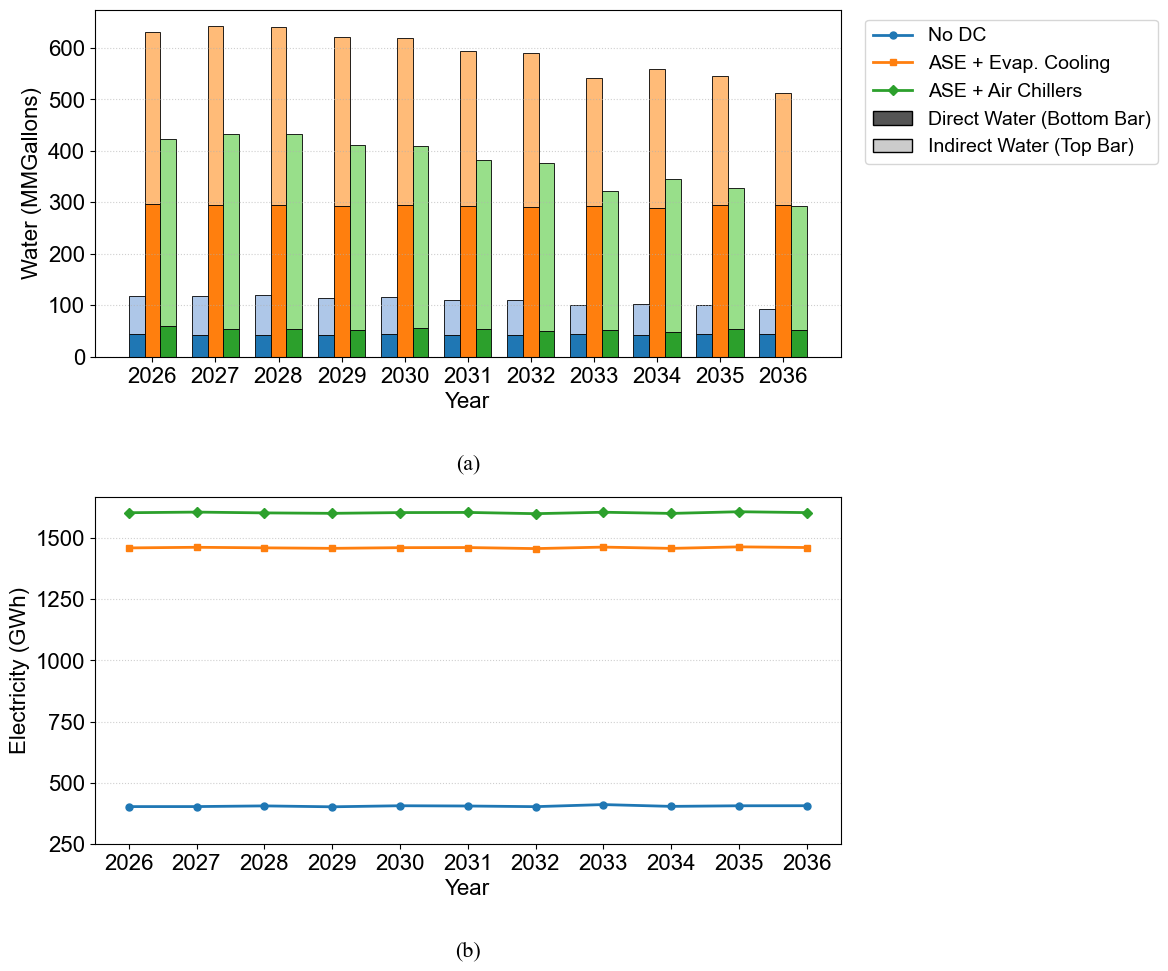

In [ ]:
using XLSX, DataFrames, PyPlot
import PyPlot.matplotlib

# ==============================================================================
# 1. PLOT STYLE & FONT CONFIGURATION (Easily change sizes here!)
# ==============================================================================
style = Dict(
    # --- FONT SIZES & FAMILY ---
    "font_family"      => "Arial", # Global font set back to Arial
    "base_font"        => 16,
    "title_size"       => 16,  
    "panel_label_size" => 20,  # Size specifically for (a) and (b)
    "axis_label"       => 16,  # X and Y axis text size
    "tick_label"       => 16,  # Number sizes on axes
    "legend_size"      => 14,  # Legend text size
    
    # --- PLOT SETTINGS ---
    "line_width"       => 2,
    "marker_size"      => 5,
    "markers"          => ["o", "s", "D"], # Circle, Square, Diamond
    
    # Adjusted to create slight gaps between the years
    "total_bar_width"  => 0.75, 
    
    # --- COLORS ---
    # Darker shades for Direct Water and Electricity Lines
    "colors_direct"    => ["#1f77b4", "#ff7f0e", "#2ca02c"], 
    # Lighter, solid pastel shades for Indirect Water
    "colors_indirect"  => ["#aec7e8", "#ffbb78", "#98df8a"] 
)

# Apply Global Font Styles
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# ==============================================================================
# 2. DATA EXTRACTION (Water & Electricity, Filter 2025)
# ==============================================================================
function get_scenario_data(filepath)
    if !isfile(filepath); return [], [], [], []; end
    
    xf = XLSX.readxlsx(filepath)
    
    # --- A. Water Extraction ---
    df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    if "Year" in names(df_w)
        filter!(row -> row.Year != 2025, df_w)
    end
    
    direct_cols = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    d_val = zeros(nrow(df_w))
    for c in direct_cols
        if c in names(df_w); d_val .+= coalesce.(df_w[!, c], 0.0); end
    end
    
    i_val = "Grid_Indirect" in names(df_w) ? coalesce.(df_w[!, "Grid_Indirect"], 0.0) : zeros(nrow(df_w))
    yrs = df_w[!, "Year"]
    
    # --- B. Electricity Extraction ---
    df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
    if "Year" in names(df_e)
        filter!(row -> row.Year != 2025, df_e)
    end
    
    gen_cols = [c for c in names(df_e) if c != "Year"]
    e_val = zeros(nrow(df_e))
    for c in gen_cols
        e_val .+= coalesce.(df_e[!, c], 0.0)
    end
    
    return yrs, d_val, i_val, e_val
end

# ==============================================================================
# 3. LOAD DATA
# ==============================================================================
scenarios = [
    ("No DC",  "Results_No_DC.xlsx"),
    ("ASE + Evap. Cooling", "Results_DC_Case_1.xlsx"),
    ("ASE + Air Chillers", "Results_DC_Case_6.xlsx")
]

data_store = Dict()
years_list = []

println("--- Extracting Water and Electricity Data ---")
for (label, file) in scenarios
    yrs, d_val, i_val, e_val = get_scenario_data(file)
    if !isempty(d_val)
        data_store[label] = (yrs, d_val, i_val, e_val)
        global years_list = yrs
    end
end

# ==============================================================================
# 4. PLOT 1: ANNUAL PROFILE (2 Rows: Top = Water, Bottom = Electricity)
# ==============================================================================
fig1, (ax1_w, ax1_e) = subplots(2, 1, figsize=(12, 10))

n_scenarios = length(scenarios)
bar_w = style["total_bar_width"] / n_scenarios
offsets = collect(range(-style["total_bar_width"]/2 + bar_w/2, stop=style["total_bar_width"]/2 - bar_w/2, length=n_scenarios))

common_years = isempty(years_list) ? [] : years_list

for (i, (label, _)) in enumerate(scenarios)
    if haskey(data_store, label)
        yrs, d_val, i_val, e_val = data_store[label]
        
        x_indices = [findfirst(x -> x == y, common_years) for y in yrs]
        x_pos = x_indices .+ offsets[i] # Used for bars only
        
        # Plot Water (Solid colors, no hatch)
        ax1_w.bar(x_pos, d_val, width=bar_w, color=style["colors_direct"][i], edgecolor="black", linewidth=0.6)
        ax1_w.bar(x_pos, i_val, width=bar_w, bottom=d_val, color=style["colors_indirect"][i], edgecolor="black", linewidth=0.6)
        
        # Plot Electricity (With distinct markers)
        ax1_e.plot(x_indices, e_val, color=style["colors_direct"][i], marker=style["markers"][i], markersize=style["marker_size"], linestyle="-", linewidth=style["line_width"], label=label)
    end
end

# Formatting Top Subplot (Water)
ax1_w.set_ylabel("Water (MMGallons)")
# Adding a newline "\n" to reserve visual space for the (a) label below it
ax1_w.set_xlabel("Year\n") 
ax1_w.grid(axis="y", linestyle=":", alpha=0.6)

# Custom text for (a) strictly in Times New Roman, normal weight, centered at the bottom
ax1_w.text(0.5, -0.28, "(a)", transform=ax1_w.transAxes, ha="center", va="top", 
           family="Times New Roman", fontsize=16, fontweight="normal")

# Formatting Bottom Subplot (Electricity)
ax1_e.set_ylabel("Electricity (GWh)")
# Adding a newline "\n" to reserve visual space for the (b) label below it
ax1_e.set_xlabel("Year\n")
ax1_e.grid(axis="y", linestyle=":", alpha=0.6)
ax1_e.set_ylim(bottom=250) # Forces Y-axis to start at 250

# Custom text for (b) strictly in Times New Roman, normal weight, centered at the bottom
ax1_e.text(0.5, -0.28, "(b)", transform=ax1_e.transAxes, ha="center", va="top", 
           family="Times New Roman", fontsize=16, fontweight="normal")

# Apply X-ticks to BOTH subplots
if !isempty(common_years)
    ax1_w.set_xticks(1:length(common_years))
    ax1_w.set_xticklabels(Int.(common_years), rotation=0)
    
    ax1_e.set_xticks(1:length(common_years))
    ax1_e.set_xticklabels(Int.(common_years), rotation=0)
end

# ==============================================================================
# 5. UNIFIED PROFESSIONAL LEGEND
# ==============================================================================
Patch = matplotlib.patches.Patch
Line2D = matplotlib.lines.Line2D

legend_elements = [
    # Lines denote the scenarios
    Line2D([0], [0], color=style["colors_direct"][1], lw=style["line_width"], marker=style["markers"][1], markersize=style["marker_size"], label=scenarios[1][1]),
    Line2D([0], [0], color=style["colors_direct"][2], lw=style["line_width"], marker=style["markers"][2], markersize=style["marker_size"], label=scenarios[2][1]),
    Line2D([0], [0], color=style["colors_direct"][3], lw=style["line_width"], marker=style["markers"][3], markersize=style["marker_size"], label=scenarios[3][1]),
    
    # Generic patches explain the stacked bar shading
    Patch(facecolor="#555555", edgecolor="black", label="Direct Water (Bottom Bar)"),
    Patch(facecolor="#cccccc", edgecolor="black", label="Indirect Water (Top Bar)")
]

# Place legend outside the plot area so it doesn't cover data
ax1_w.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1.0))

# Use h_pad to ensure the labels don't overlap between the top and bottom plots
tight_layout(h_pad=1.0)

# Save at high resolution
# savefig("Annual_Resource_Profiles_baseline.pdf", dpi=600, bbox_inches="tight")
display(fig1)

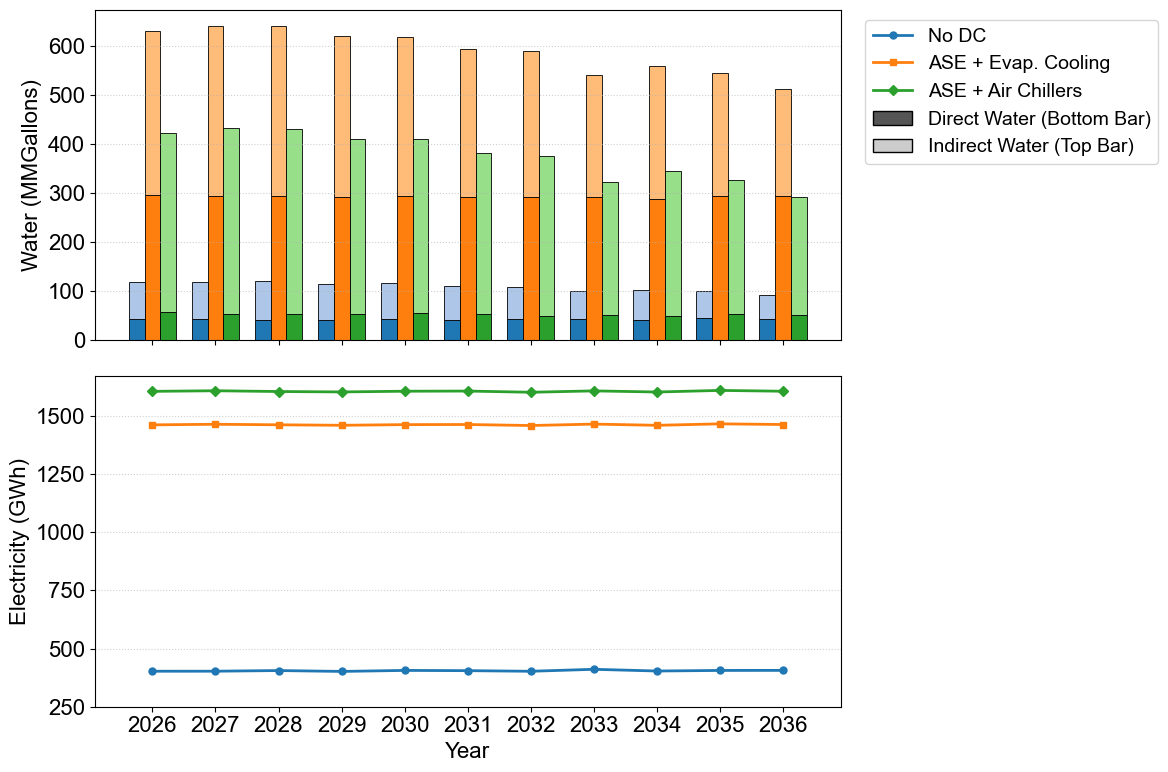

--- Extracting Water and Electricity Data ---


In [14]:
using XLSX, DataFrames, PyPlot
import PyPlot.matplotlib

# ==============================================================================
# 1. PLOT STYLE & FONT CONFIGURATION (Easily change sizes here!)
# ==============================================================================
style = Dict(
    # --- FONT SIZES ---
    "font_family"   => "Arial",
    "base_font"     => 16,
    "title_size"    => 16,  # Main title size
    "axis_label"    => 16,  # X and Y axis text size
    "tick_label"    => 16,  # Number sizes on axes
    "legend_size"   => 14,  # Legend text size
    
    # --- PLOT SETTINGS ---
    "line_width"    => 2,
    "marker_size"   => 5,
    "markers"       => ["o", "s", "D"], # Circle, Square, Diamond
    
    # Adjusted to create slight gaps between the years
    "total_bar_width" => 0.75, 
    
    # --- COLORS ---
    # Darker shades for Direct Water and Electricity Lines
    "colors_direct"   => ["#1f77b4", "#ff7f0e", "#2ca02c"], 
    # Lighter, solid pastel shades for Indirect Water (No more hatching)
    "colors_indirect" => ["#aec7e8", "#ffbb78", "#98df8a"] 
)

# Apply Global Font Styles
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# ==============================================================================
# 2. DATA EXTRACTION (Water & Electricity, Filter 2025)
# ==============================================================================
function get_scenario_data(filepath)
    if !isfile(filepath); return [], [], [], []; end
    
    xf = XLSX.readxlsx(filepath)
    
    # --- A. Water Extraction ---
    df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    if "Year" in names(df_w)
        filter!(row -> row.Year != 2025, df_w)
    end
    
    direct_cols = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    d_val = zeros(nrow(df_w))
    for c in direct_cols
        if c in names(df_w); d_val .+= coalesce.(df_w[!, c], 0.0); end
    end
    
    i_val = "Grid_Indirect" in names(df_w) ? coalesce.(df_w[!, "Grid_Indirect"], 0.0) : zeros(nrow(df_w))
    yrs = df_w[!, "Year"]
    
    # --- B. Electricity Extraction ---
    df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
    if "Year" in names(df_e)
        filter!(row -> row.Year != 2025, df_e)
    end
    
    gen_cols = [c for c in names(df_e) if c != "Year"]
    e_val = zeros(nrow(df_e))
    for c in gen_cols
        e_val .+= coalesce.(df_e[!, c], 0.0)
    end
    
    return yrs, d_val, i_val, e_val
end

# ==============================================================================
# 3. LOAD DATA
# ==============================================================================
scenarios = [
    ("No DC",  "Results_No_DC.xlsx"),
    ("ASE + Evap. Cooling", "Results_DC_Case_1.xlsx"),
    ("ASE + Air Chillers", "Results_DC_Case_6.xlsx")
]

data_store = Dict()
years_list = []

println("--- Extracting Water and Electricity Data ---")
for (label, file) in scenarios
    yrs, d_val, i_val, e_val = get_scenario_data(file)
    if !isempty(d_val)
        data_store[label] = (yrs, d_val, i_val, e_val)
        global years_list = yrs
    end
end

# ==============================================================================
# 4. PLOT 1: ANNUAL PROFILE (2 Rows: Top = Water, Bottom = Electricity)
# ==============================================================================
fig1, (ax1_w, ax1_e) = subplots(2, 1, figsize=(12, 8), sharex=true)

n_scenarios = length(scenarios)
bar_w = style["total_bar_width"] / n_scenarios
offsets = collect(range(-style["total_bar_width"]/2 + bar_w/2, stop=style["total_bar_width"]/2 - bar_w/2, length=n_scenarios))

common_years = isempty(years_list) ? [] : years_list

for (i, (label, _)) in enumerate(scenarios)
    if haskey(data_store, label)
        yrs, d_val, i_val, e_val = data_store[label]
        
        x_indices = [findfirst(x -> x == y, common_years) for y in yrs]
        x_pos = x_indices .+ offsets[i] # Used for bars only
        
        # Plot Water (Solid colors, no hatch)
        ax1_w.bar(x_pos, d_val, width=bar_w, color=style["colors_direct"][i], edgecolor="black", linewidth=0.6)
        ax1_w.bar(x_pos, i_val, width=bar_w, bottom=d_val, color=style["colors_indirect"][i], edgecolor="black", linewidth=0.6)
        
        # Plot Electricity (With distinct markers)
        ax1_e.plot(x_indices, e_val, color=style["colors_direct"][i], marker=style["markers"][i], markersize=style["marker_size"], linestyle="-", linewidth=style["line_width"], label=label)
    end
end

# Formatting Top Subplot (Water)
# ax1_w.set_title("Annual Resource Consumption Profiles", fontweight="bold")
ax1_w.set_ylabel("Water (MMGallons)")
ax1_w.grid(axis="y", linestyle=":", alpha=0.6)

# Formatting Bottom Subplot (Electricity)
ax1_e.set_ylabel("Electricity (GWh)")
ax1_e.set_xlabel("Year")
ax1_e.grid(axis="y", linestyle=":", alpha=0.6)
ax1_e.set_ylim(bottom=250) # Forces Y-axis to start at 0

if !isempty(common_years)
    ax1_e.set_xticks(1:length(common_years))
    ax1_e.set_xticklabels(Int.(common_years), rotation=0)
end

# ==============================================================================
# 5. UNIFIED PROFESSIONAL LEGEND
# ==============================================================================
Patch = matplotlib.patches.Patch
Line2D = matplotlib.lines.Line2D

legend_elements = [
    # Lines denote the scenarios
    Line2D([0], [0], color=style["colors_direct"][1], lw=style["line_width"], marker=style["markers"][1], markersize=style["marker_size"], label=scenarios[1][1]),
    Line2D([0], [0], color=style["colors_direct"][2], lw=style["line_width"], marker=style["markers"][2], markersize=style["marker_size"], label=scenarios[2][1]),
    Line2D([0], [0], color=style["colors_direct"][3], lw=style["line_width"], marker=style["markers"][3], markersize=style["marker_size"], label=scenarios[3][1]),
    
    # Generic patches explain the stacked bar shading
    Patch(facecolor="#555555", edgecolor="black", label="Direct Water (Bottom Bar)"),
    Patch(facecolor="#cccccc", edgecolor="black", label="Indirect Water (Top Bar)")
]

# Place legend outside the plot area so it doesn't cover data
ax1_w.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1.0))

tight_layout()

# Save at high resolution
# savefig("Annual_Resource_Profiles_baseline.png", dpi=600, bbox_inches="tight")
display(fig1)

--- Extracting Water and Electricity Data ---


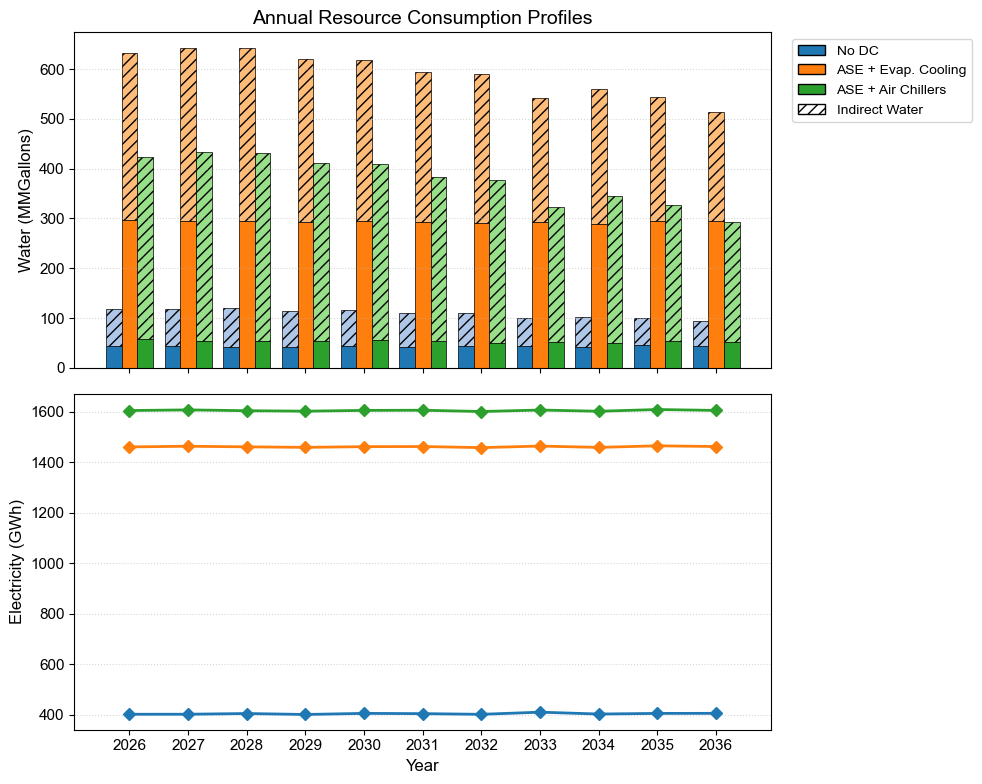

In [1]:
using XLSX, DataFrames, PyPlot

# ==============================================================================
# 1. PLOT STYLE CONFIGURATION
# ==============================================================================
style = Dict(
    "font_family"   => "Arial",
    "base_font"     => 12,
    "title_size"    => 14,
    "axis_label"    => 12,
    "tick_label"    => 11,
    "legend_size"   => 10,
    
    # Line Plot Settings
    "line_width"    => 2.0,
    "marker_size"   => 6,
    
    # Bar Plot Settings
    "bar_width"     => 0.25,
    "bar_width_wide"=> 0.4, # For the side-by-side cumulative plot
    
    # Colors (Direct, Indirect, Lines)
    "colors_direct"   => ["#1f77b4", "#ff7f0e", "#2ca02c"], 
    "colors_indirect" => ["#aec7e8", "#ffbb78", "#98df8a"], 
    "colors_lines"    => ["#1f77b4", "#ff7f0e", "#2ca02c"] # Darker shades for lines
)

# Apply Global Styles
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# ==============================================================================
# 2. DATA EXTRACTION (Water & Electricity, Filter 2025)
# ==============================================================================
function get_scenario_data(filepath)
    if !isfile(filepath); return [], [], [], []; end
    
    xf = XLSX.readxlsx(filepath)
    
    # --- A. Water Extraction ---
    df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    if "Year" in names(df_w)
        filter!(row -> row.Year != 2025, df_w)
    end
    
    direct_cols = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    d_val = zeros(nrow(df_w))
    for c in direct_cols
        if c in names(df_w); d_val .+= coalesce.(df_w[!, c], 0.0); end
    end
    
    i_val = "Grid_Indirect" in names(df_w) ? coalesce.(df_w[!, "Grid_Indirect"], 0.0) : zeros(nrow(df_w))
    yrs = df_w[!, "Year"]
    
    # --- B. Electricity Extraction ---
    df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
    if "Year" in names(df_e)
        filter!(row -> row.Year != 2025, df_e)
    end
    
    gen_cols = [c for c in names(df_e) if c != "Year"]
    e_val = zeros(nrow(df_e))
    for c in gen_cols
        e_val .+= coalesce.(df_e[!, c], 0.0)
    end
    
    return yrs, d_val, i_val, e_val
end

# ==============================================================================
# 3. LOAD DATA
# ==============================================================================
scenarios = [
    ("No DC",  "Results_No_DC.xlsx"),
    ("ASE + Evap. Cooling", "Results_DC_Case_1.xlsx"),
    ("ASE + Air Chillers", "Results_DC_Case_6.xlsx")
]

data_store = Dict()
years_list = []

println("--- Extracting Water and Electricity Data ---")
for (label, file) in scenarios
    yrs, d_val, i_val, e_val = get_scenario_data(file)
    if !isempty(d_val)
        data_store[label] = (yrs, d_val, i_val, e_val)
        global years_list = yrs
    end
end

# ==============================================================================
# 4. PLOT 1: ANNUAL PROFILE (2 Rows: Top = Water, Bottom = Electricity)
# ==============================================================================
fig1, (ax1_w, ax1_e) = subplots(2, 1, figsize=(10, 8), sharex=true)

n_scenarios = length(scenarios)
total_width = 0.8
bar_w = total_width / n_scenarios
offsets = collect(range(-total_width/2 + bar_w/2, stop=total_width/2 - bar_w/2, length=n_scenarios))

common_years = isempty(years_list) ? [] : years_list

for (i, (label, _)) in enumerate(scenarios)
    if haskey(data_store, label)
        yrs, d_val, i_val, e_val = data_store[label]
        
        x_indices = [findfirst(x -> x == y, common_years) for y in yrs]
        x_pos = x_indices .+ offsets[i] # Used for bars only
        
        # Plot Water (Top Subplot)
        ax1_w.bar(x_pos, d_val, width=bar_w, color=style["colors_direct"][i], edgecolor="black", linewidth=0.5)
        ax1_w.bar(x_pos, i_val, width=bar_w, bottom=d_val, color=style["colors_indirect"][i], edgecolor="black", linewidth=0.5, hatch="///")
        
        # Plot Electricity (Bottom Subplot)
        ax1_e.plot(x_indices, e_val, color=style["colors_lines"][i], marker="D", markersize=style["marker_size"], linestyle="-", linewidth=style["line_width"], label=label)
    end
end

# Formatting Top Subplot (Water)
ax1_w.set_title("Annual Resource Consumption Profiles")
ax1_w.set_ylabel("Water (MMGallons)")
ax1_w.grid(axis="y", linestyle=":", alpha=0.5)

# Formatting Bottom Subplot (Electricity)
ax1_e.set_ylabel("Electricity (GWh)")
ax1_e.set_xlabel("Year")
ax1_e.grid(axis="y", linestyle=":", alpha=0.5)

if !isempty(common_years)
    ax1_e.set_xticks(1:length(common_years))
    ax1_e.set_xticklabels(Int.(common_years), rotation=0)
end

# Unified Legend for Figure 1 (Placed on the top subplot)
Patch = PyPlot.matplotlib.patches.Patch
legend_elements = []
for (i, (label, _)) in enumerate(scenarios)
    push!(legend_elements, Patch(facecolor=style["colors_direct"][i], edgecolor="black", label=label))
end
push!(legend_elements, Patch(facecolor="white", edgecolor="black", hatch="///", label="Indirect Water"))

ax1_w.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1))

tight_layout()
display(fig1)



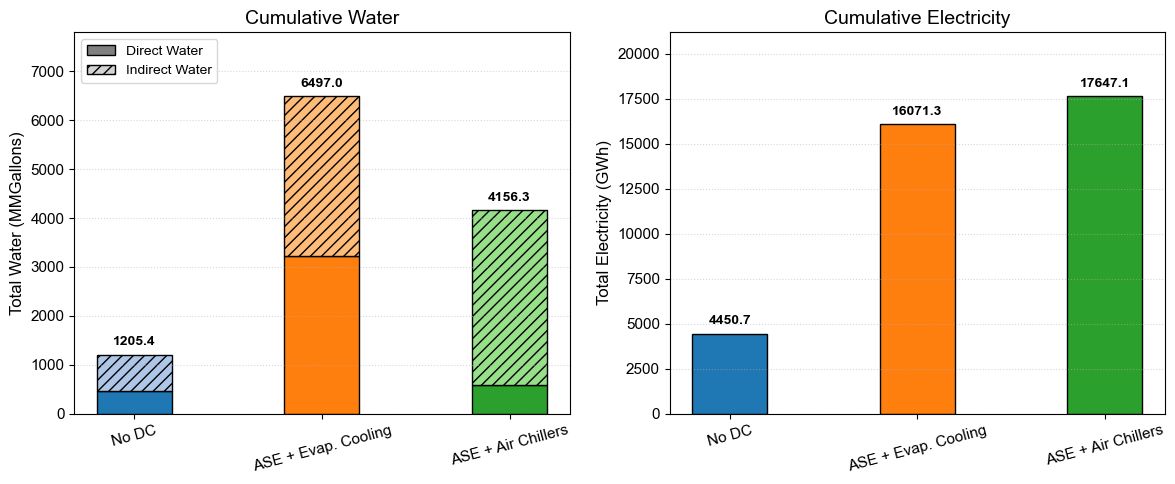

In [2]:

# ==============================================================================
# 5. PLOT 2: CUMULATIVE (1 Row, 2 Columns: Left = Water, Right = Electricity)
# ==============================================================================
fig2, (ax2_w, ax2_e) = subplots(1, 2, figsize=(12, 5))

valid_scenarios = [s for s in scenarios if haskey(data_store, s[1])]
labels = [s[1] for s in valid_scenarios]

if !isempty(labels)
    direct_sums   = [sum(data_store[s[1]][2]) for s in valid_scenarios]
    indirect_sums = [sum(data_store[s[1]][3]) for s in valid_scenarios]
    elec_sums     = [sum(data_store[s[1]][4]) for s in valid_scenarios]
    total_w_sums  = direct_sums .+ indirect_sums

    x_pos = 0:(length(labels)-1)

    # --- LEFT SUBPLOT: WATER ---
    ax2_w.bar(x_pos, direct_sums, width=style["bar_width_wide"], color=[style["colors_direct"][i] for i in 1:length(labels)], edgecolor="black")
    ax2_w.bar(x_pos, indirect_sums, width=style["bar_width_wide"], bottom=direct_sums, color=[style["colors_indirect"][i] for i in 1:length(labels)], edgecolor="black", hatch="///")

    ax2_w.set_title("Cumulative Water")
    ax2_w.set_ylabel("Total Water (MMGallons)")
    ax2_w.set_xticks(x_pos)
    ax2_w.set_xticklabels(labels, rotation=15, ha="center")
    ax2_w.grid(axis="y", linestyle=":", alpha=0.5)
    ax2_w.set_ylim(0, maximum(total_w_sums) * 1.20)

    # Data Labels for Water
    for (i, t_val) in enumerate(total_w_sums)
        ax2_w.text(i-1, t_val + (maximum(total_w_sums)*0.02), string(round(t_val, digits=1)), ha="center", va="bottom", fontsize=10, fontweight="bold")
    end

    # Legend for Water
    w_legend_elements = [
        Patch(facecolor="gray", edgecolor="black", label="Direct Water"),
        Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="Indirect Water")
    ]
    ax2_w.legend(handles=w_legend_elements, loc="upper left")


    # --- RIGHT SUBPLOT: ELECTRICITY ---
    # Now using standard bars instead of a scatter marker
    ax2_e.bar(x_pos, elec_sums, width=style["bar_width_wide"], color=[style["colors_direct"][i] for i in 1:length(labels)], edgecolor="black")

    ax2_e.set_title("Cumulative Electricity")
    ax2_e.set_ylabel("Total Electricity (GWh)")
    ax2_e.set_xticks(x_pos)
    ax2_e.set_xticklabels(labels, rotation=15, ha="center")
    ax2_e.grid(axis="y", linestyle=":", alpha=0.5)
    ax2_e.set_ylim(0, maximum(elec_sums) * 1.20)

    # Data Labels for Electricity
    for (i, e_val) in enumerate(elec_sums)
        ax2_e.text(i-1, e_val + (maximum(elec_sums)*0.02), string(round(e_val, digits=1)), ha="center", va="bottom", fontsize=10, fontweight="bold")
    end

    tight_layout()
    display(fig2)
end

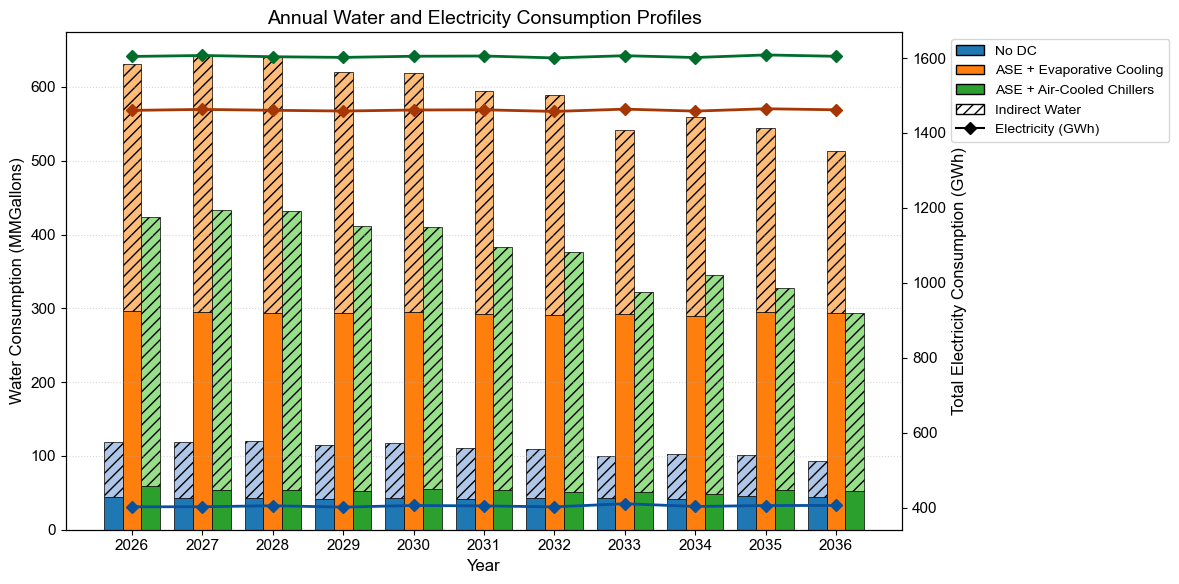

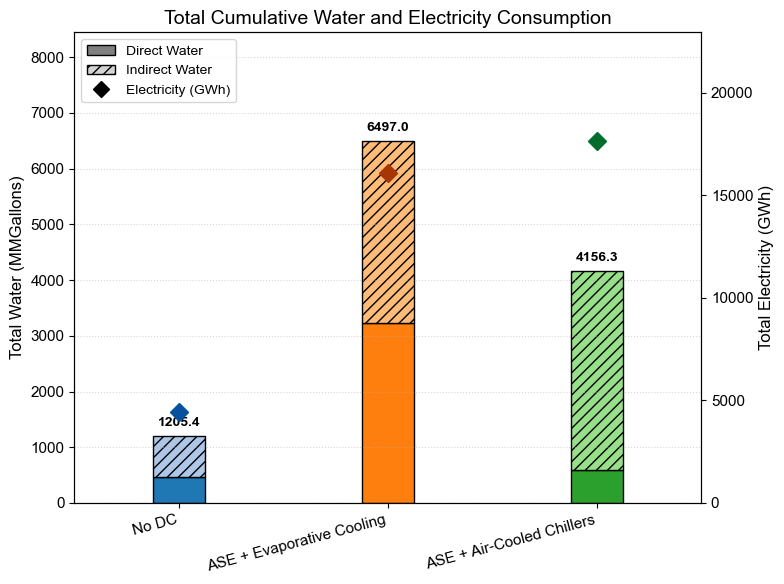

--- Extracting Water and Electricity Data ---


In [10]:
# using XLSX, DataFrames, PyPlot

# # ==============================================================================
# # 1. PLOT STYLE CONFIGURATION
# # ==============================================================================
# style = Dict(
#     "font_family"   => "Arial",
#     "base_font"     => 12,
#     "title_size"    => 14,
#     "axis_label"    => 12,
#     "tick_label"    => 11,
#     "legend_size"   => 10,
    
#     # Line Plot Settings
#     "line_width"    => 2.0,
#     "marker_size"   => 6,
    
#     # Bar Plot Settings
#     "bar_width"     => 0.25,
    
#     # Colors (Direct, Indirect, Lines)
#     "colors_direct"   => ["#1f77b4", "#ff7f0e", "#2ca02c"], 
#     "colors_indirect" => ["#aec7e8", "#ffbb78", "#98df8a"], 
#     "colors_lines"    => ["#08519c", "#a63603", "#006d2c"], # Dark Blue, Dark Orange/Rust, Dark Green
    
#     "fig_size"      => (12, 6)
# )

# # Apply Global Styles
# rc("font", family=style["font_family"], size=style["base_font"])
# rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
# rc("xtick", labelsize=style["tick_label"])
# rc("ytick", labelsize=style["tick_label"])
# rc("legend", fontsize=style["legend_size"])

# # ==============================================================================
# # 2. DATA EXTRACTION (Water & Electricity, Filter 2025)
# # ==============================================================================
# function get_scenario_data(filepath)
#     if !isfile(filepath); return [], [], [], []; end
    
#     xf = XLSX.readxlsx(filepath)
    
#     # --- A. Water Extraction ---
#     df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
#     if "Year" in names(df_w)
#         filter!(row -> row.Year != 2025, df_w)
#     end
    
#     direct_cols = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
#     d_val = zeros(nrow(df_w))
#     for c in direct_cols
#         if c in names(df_w); d_val .+= coalesce.(df_w[!, c], 0.0); end
#     end
    
#     i_val = "Grid_Indirect" in names(df_w) ? coalesce.(df_w[!, "Grid_Indirect"], 0.0) : zeros(nrow(df_w))
#     yrs = df_w[!, "Year"]
    
#     # --- B. Electricity Extraction ---
#     df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
#     if "Year" in names(df_e)
#         filter!(row -> row.Year != 2025, df_e)
#     end
    
#     gen_cols = [c for c in names(df_e) if c != "Year"]
#     e_val = zeros(nrow(df_e))
#     for c in gen_cols
#         e_val .+= coalesce.(df_e[!, c], 0.0)
#     end
    
#     return yrs, d_val, i_val, e_val
# end

# # ==============================================================================
# # 3. LOAD DATA
# # ==============================================================================
# scenarios = [
#     ("No DC",  "Results_No_DC.xlsx"),
#     ("ASE + Evaporative Cooling", "Results_DC_Case_1.xlsx"),
#     ("ASE + Air-Cooled Chillers", "Results_DC_Case_6.xlsx")
# ]

# data_store = Dict()
# years_list = []

# println("--- Extracting Water and Electricity Data ---")
# for (label, file) in scenarios
#     yrs, d_val, i_val, e_val = get_scenario_data(file)
#     if !isempty(d_val)
#         data_store[label] = (yrs, d_val, i_val, e_val)
#         global years_list = yrs
#     end
# end

# # ==============================================================================
# # 4. PLOT 1: ANNUAL PROFILE (Grouped Bars + Lines on Secondary Axis)
# # ==============================================================================
# fig1 = figure(figsize=style["fig_size"])
# ax1 = gca()
# ax1_el = ax1.twinx() # Create secondary y-axis for electricity

# n_scenarios = length(scenarios)
# total_width = 0.8
# bar_w = total_width / n_scenarios
# offsets = collect(range(-total_width/2 + bar_w/2, stop=total_width/2 - bar_w/2, length=n_scenarios))

# common_years = isempty(years_list) ? [] : years_list

# for (i, (label, _)) in enumerate(scenarios)
#     if haskey(data_store, label)
#         yrs, d_val, i_val, e_val = data_store[label]
        
#         x_indices = [findfirst(x -> x == y, common_years) for y in yrs]
#         x_pos = x_indices .+ offsets[i] # Used for bars only
        
#         # Plot Water (Bars offset to group together)
#         ax1.bar(x_pos, d_val, width=bar_w, color=style["colors_direct"][i], edgecolor="black", linewidth=0.5)
#         ax1.bar(x_pos, i_val, width=bar_w, bottom=d_val, color=style["colors_indirect"][i], edgecolor="black", linewidth=0.5, hatch="///")
        
#         # Plot Electricity (Lines centered perfectly on the year tick using darker colors)
#         ax1_el.plot(x_indices, e_val, color=style["colors_lines"][i], marker="D", markersize=style["marker_size"], linestyle="-", linewidth=style["line_width"])
#     end
# end

# ax1.set_title("Annual Water and Electricity Consumption Profiles")
# ax1.set_ylabel("Water Consumption (MMGallons)")
# ax1.set_xlabel("Year")
# ax1_el.set_ylabel("Total Electricity Consumption (GWh)")

# if !isempty(common_years)
#     ax1.set_xticks(1:length(common_years))
#     ax1.set_xticklabels(Int.(common_years), rotation=0)
# end

# ax1.grid(axis="y", linestyle=":", alpha=0.5)

# # Custom Unified Legend
# Patch = PyPlot.matplotlib.patches.Patch
# Line2D = PyPlot.matplotlib.lines.Line2D

# legend_elements = []
# for (i, (label, _)) in enumerate(scenarios)
#     push!(legend_elements, Patch(facecolor=style["colors_direct"][i], edgecolor="black", label=label))
# end
# push!(legend_elements, Patch(facecolor="white", edgecolor="black", hatch="///", label="Indirect Water"))
# push!(legend_elements, Line2D([0], [0], color="black", marker="D", linestyle="-", label="Electricity (GWh)"))

# ax1.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.05, 1))
# tight_layout()
# display(fig1)

# # ==============================================================================
# # 5. PLOT 2: CUMULATIVE STACKED BAR (Water) + SCATTER (Electricity)
# # ==============================================================================
# fig2 = figure(figsize=(8, 6))
# ax2 = gca()
# ax2_el = ax2.twinx() # Secondary axis

# valid_scenarios = [s for s in scenarios if haskey(data_store, s[1])]
# labels = [s[1] for s in valid_scenarios]

# if !isempty(labels)
#     direct_sums   = [sum(data_store[s[1]][2]) for s in valid_scenarios]
#     indirect_sums = [sum(data_store[s[1]][3]) for s in valid_scenarios]
#     elec_sums     = [sum(data_store[s[1]][4]) for s in valid_scenarios]
#     total_w_sums  = direct_sums .+ indirect_sums

#     x_pos = 0:(length(labels)-1)

#     # Plot Water Bars
#     ax2.bar(x_pos, direct_sums, width=style["bar_width"], color=[style["colors_direct"][i] for i in 1:length(labels)], edgecolor="black")
#     ax2.bar(x_pos, indirect_sums, width=style["bar_width"], bottom=direct_sums, color=[style["colors_indirect"][i] for i in 1:length(labels)], edgecolor="black", hatch="///")

#     # Plot Electricity Markers (Darker colors to match lines above)
#     for i in 1:length(labels)
#         ax2_el.plot(x_pos[i], elec_sums[i], color=style["colors_lines"][i], marker="D", linestyle="", markersize=9)
#     end

#     ax2.set_title("Total Cumulative Water and Electricity Consumption")
#     ax2.set_ylabel("Total Water (MMGallons)")
#     ax2_el.set_ylabel("Total Electricity (GWh)")
#     ax2.set_xticks(x_pos)
#     ax2.set_xticklabels(labels, rotation=15, ha="right")
#     ax2.grid(axis="y", linestyle=":", alpha=0.5)

#     # FIX 1 & 2: Adjust limits for extra headroom and X-axis padding
#     ax2.set_ylim(0, maximum(total_w_sums) * 1.30)
#     ax2_el.set_ylim(0, maximum(elec_sums) * 1.30)
#     ax2.set_xlim(-0.5, length(labels) - 0.5)

#     # Add Data Labels for Water (Above Bars)
#     for (i, t_val) in enumerate(total_w_sums)
#         ax2.text(i-1, t_val + (maximum(total_w_sums)*0.02), string(round(t_val, digits=1)), ha="center", va="bottom", fontsize=10, fontweight="bold")
#     end
    
#     # # FIX 3: Center Data Labels for Electricity above the markers
#     # for (i, e_val) in enumerate(elec_sums)
#     #     ax2_el.text(i-1, e_val + (maximum(elec_sums)*0.03), string(round(e_val, digits=1)), ha="center", va="bottom", fontsize=10, fontweight="bold", color="black")
#     # end

#     # FIX 4: Move Legend inside the plot to the upper left
#     legend_elements_2 = [
#         Patch(facecolor="gray", edgecolor="black", label="Direct Water"),
#         Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="Indirect Water"),
#         Line2D([0], [0], color="black", marker="D", linestyle="", markersize=8, label="Electricity (GWh)")
#     ]
#     ax2.legend(handles=legend_elements_2, loc="upper left")

#     tight_layout()
#     display(fig2)
# end

##### Figure X. Annual (top) and cumulative (bottom) resource consumption across the modeled system boundaries. The primary y-axis (left, stacked bars) illustrates direct and indirect water consumption in million gallons (MMGal). The secondary y-axis (right, lines and diamond markers) tracks the total electricity consumption in gigawatt-hours (GWh). Scenarios evaluate the underlying resource trade-offs between the baseline without a data center ("No DC"), a data center utilizing an airside economizer paired with evaporative cooling ("ASE + Evaporative Cooling"), and a data center utilizing an airside economizer paired with air-cooled chillers ("ASE + Air-Cooled Chillers").

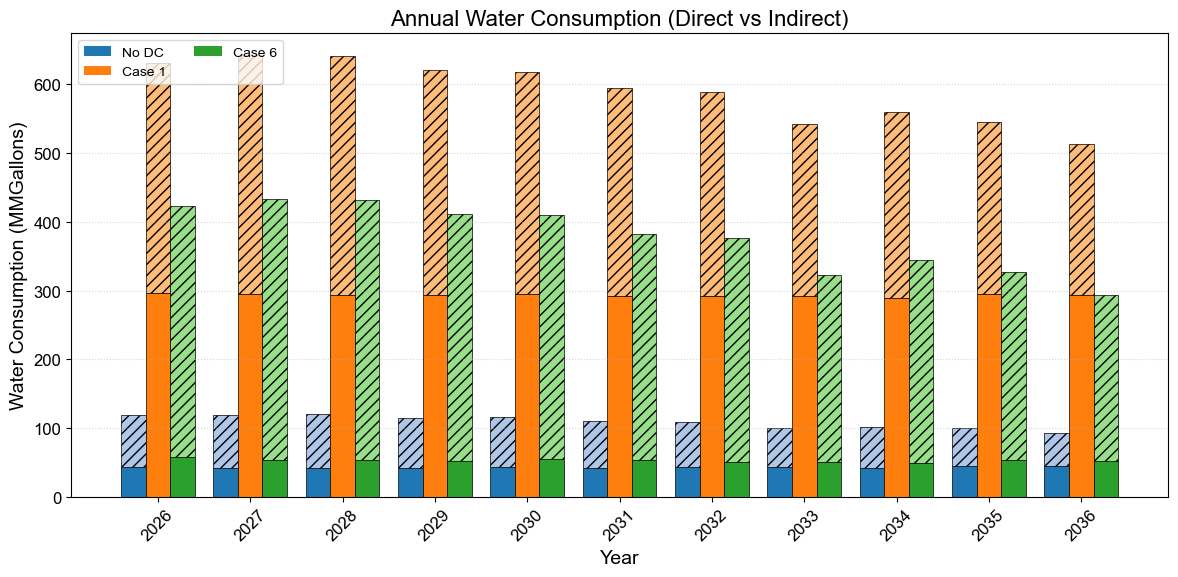

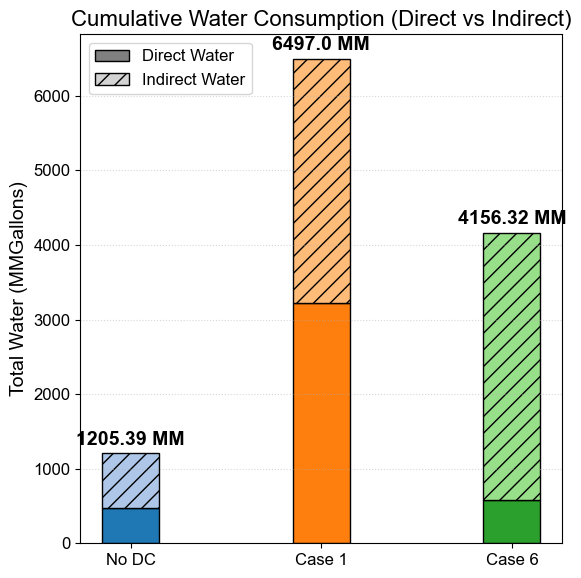

In [2]:
using XLSX, DataFrames, PyPlot

# ==============================================================================
# 1. PLOT STYLE CONFIGURATION
# ==============================================================================
style = Dict(
    "font_family"   => "Arial",
    "base_font"     => 14,
    "title_size"    => 16,
    "axis_label"    => 14,
    "tick_label"    => 12,
    "legend_size"   => 12,
    
    # Line Plot Settings
    "line_width"    => 2.5,
    "marker_size"   => 8,
    
    # Bar Plot Settings
    "bar_width"     => 0.3,
    
    # Colors (Direct, Indirect)
    # We use tuples: (Direct Color, Indirect Color)
    # Scenario 1 (Blueish), Scenario 2 (Orangish), Scenario 3 (Greenish)
    "colors_direct"   => ["#1f77b4", "#ff7f0e", "#2ca02c"], 
    "colors_indirect" => ["#aec7e8", "#ffbb78", "#98df8a"], # Lighter shades
    
    "fig_size"      => (6, 6)
)

# Apply Global Styles
rc("font", family=style["font_family"], size=style["base_font"])
rc("axes", titlesize=style["title_size"], labelsize=style["axis_label"])
rc("xtick", labelsize=style["tick_label"])
rc("ytick", labelsize=style["tick_label"])
rc("legend", fontsize=style["legend_size"])

# ==============================================================================
# 2. DATA EXTRACTION (Split Direct vs Indirect, Filter 2025)
# ==============================================================================
function get_water_split(filepath)
    if !isfile(filepath); return [], [], []; end
    
    xf = XLSX.readxlsx(filepath)
    if "Water_Consumption" ∉ XLSX.sheetnames(xf); return [], [], []; end
    
    df = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    
    # 1. Filter out Year 2025
    # We assume the 'Year' column exists and is numeric or string "2025"
    if "Year" in names(df)
        filter!(row -> row.Year != 2025, df)
    end
    
    # 2. Identify Columns (Reverted to original names)
    direct_cols = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    indirect_col = "Grid_Indirect"
    
    # 3. Sum Direct
    valid_d_cols = [c for c in direct_cols if c in names(df)]
    direct_vals = zeros(nrow(df))
    for c in valid_d_cols
        direct_vals .+= coalesce.(df[!, c], 0.0)
    end
    
    # 4. Get Indirect
    indirect_vals = zeros(nrow(df))
    if indirect_col in names(df)
        indirect_vals = coalesce.(df[!, indirect_col], 0.0)
    end
    
    return df[!, "Year"], direct_vals, indirect_vals
end

# ==============================================================================
# 3. LOAD DATA
# ==============================================================================
scenarios = [
    ("No DC",  "Results_No_DC.xlsx"),
    ("Case 1", "Results_DC_Case_1.xlsx"),
    ("Case 6", "Results_DC_Case_6.xlsx")
]

# Store data in Dictionary: Label -> (Years, Direct, Indirect)
data_store = Dict()
years_list = []

for (label, file) in scenarios
    yrs, d_val, i_val = get_water_split(file)
    if !isempty(d_val)
        # Data is already in MMGallons, no conversion needed
        data_store[label] = (yrs, d_val, i_val)
        global years_list = yrs
    end
end

# ==============================================================================
# 4. PLOT 1: ANNUAL PROFILE (Grouped Stacked Bars)
# ==============================================================================
fig1 = figure(figsize=(12, 6)) # Slightly wider to fit grouped bars
ax1 = gca()

# Configuration for grouping
n_scenarios = length(scenarios)
total_width = 0.8  # Total width of the group per year
bar_w = total_width / n_scenarios
offsets = collect(range(-total_width/2 + bar_w/2, stop=total_width/2 - bar_w/2, length=n_scenarios))

# We need a common list of years for the X-axis
# (Assuming all scenarios cover the same years after filtering 2025)
common_years = []
if !isempty(years_list)
    common_years = years_list
end

for (i, (label, _)) in enumerate(scenarios)
    if haskey(data_store, label)
        # Unpack data
        yrs, d_val, i_val = data_store[label]
        
        # Calculate X positions for this specific scenario
        # We find the index of each year in 'common_years' to place it correctly
        x_indices = [findfirst(x -> x == y, common_years) for y in yrs]
        
        # If years match perfectly, x_indices is just 1:N. 
        # But we add the offset for this scenario.
        x_pos = x_indices .+ offsets[i]
        
        # 1. Plot Direct (Solid)
        ax1.bar(x_pos, d_val, 
                width=bar_w, 
                color=style["colors_direct"][i], 
                edgecolor="black", 
                linewidth=0.5,
                label=(i==1 ? "Direct" : "")) # Only label once for legend
        
        # 2. Plot Indirect (Hatched, Stacked on Direct)
        ax1.bar(x_pos, i_val, 
                width=bar_w, 
                bottom=d_val, # Stack on top of direct
                color=style["colors_indirect"][i], 
                edgecolor="black", 
                linewidth=0.5,
                hatch="///", # Hatch pattern
                label=(i==1 ? "Indirect" : ""))
    end
end

title("Annual Water Consumption (Direct vs Indirect)")
ylabel("Water Consumption (MMGallons)")
xlabel("Year")

# Set X-ticks to the center of the groups (Integers)
if !isempty(common_years)
    ax1.set_xticks(1:length(common_years))
    ax1.set_xticklabels(Int.(common_years), rotation=45)
end

grid(axis="y", linestyle=":", alpha=0.5)

# Custom Legend to explain Colors + Hatching
# We need to explain: Colors = Scenario, Texture = Direct/Indirect
Patch = PyPlot.matplotlib.patches.Patch

legend_handles = []
# B. Add Color Legend
for (i, (label, _)) in enumerate(scenarios)
    push!(legend_handles, Patch(facecolor=style["colors_direct"][i], label=label))
end

ax1.legend(handles=legend_handles, loc="upper left", ncol=2, fontsize=10)

tight_layout()
display(fig1)

# ==============================================================================
# 5. PLOT 2: CUMULATIVE STACKED BAR (Direct + Indirect)
# ==============================================================================
fig2 = figure(figsize=style["fig_size"])
ax2 = gca()

# Filter only scenarios that exist in data
valid_scenarios = [s for s in scenarios if haskey(data_store, s[1])]
labels = [s[1] for s in valid_scenarios]

if isempty(labels)
    println("⚠️ No valid data found to plot!")
else
    # Calculate Sums
    direct_sums   = [sum(data_store[s[1]][2]) for s in valid_scenarios]
    indirect_sums = [sum(data_store[s[1]][3]) for s in valid_scenarios]
    total_sums    = direct_sums .+ indirect_sums

    x_pos = 0:(length(labels)-1)

    # Plot Direct (Bottom Bar)
    p1 = ax2.bar(x_pos, direct_sums, 
                 width=style["bar_width"], 
                 color=style["colors_direct"][1:length(labels)], 
                 label="Direct", edgecolor="black")

    # Plot Indirect (Top Bar)
    p2 = ax2.bar(x_pos, indirect_sums, 
                 width=style["bar_width"], 
                 bottom=direct_sums, 
                 color=style["colors_indirect"][1:length(labels)], 
                 label="Indirect", edgecolor="black", hatch="//")

    title("Cumulative Water Consumption (Direct vs Indirect)")
    ylabel("Total Water (MMGallons)")
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels)
    grid(axis="y", linestyle=":", alpha=0.5)

    # Add Total Value Labels on Top
    for (i, t_val) in enumerate(total_sums)
        ax2.text(i-1, t_val + (maximum(total_sums)*0.01), 
                 string(round(t_val, digits=2)) * " MM", 
                 ha="center", va="bottom", fontweight="bold")
    end

    # We access the Python 'Patch' object via PyPlot.matplotlib
    Patch = PyPlot.matplotlib.patches.Patch

    legend_elements = [
        Patch(facecolor="gray", edgecolor="black", label="Direct Water"),
        Patch(facecolor="lightgray", edgecolor="black", hatch="//", label="Indirect Water")
    ]
    
    # Create legend using the custom handles
    ax2.legend(handles=legend_elements, loc="upper left")

    tight_layout()
    display(fig2)
end

--- Extracting DC Electricity ---
   -> No explicit DC column. Calculating (Total Gen - Baseline Gen)...
   -> No explicit DC column. Calculating (Total Gen - Baseline Gen)...


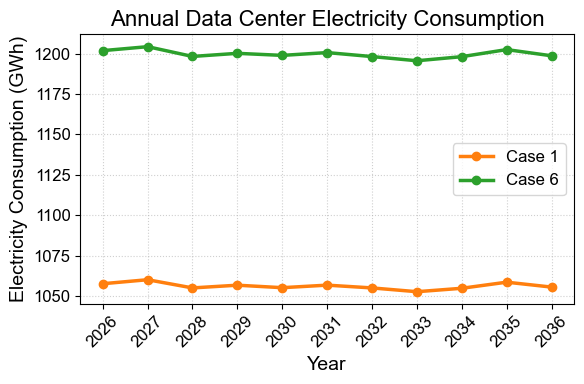

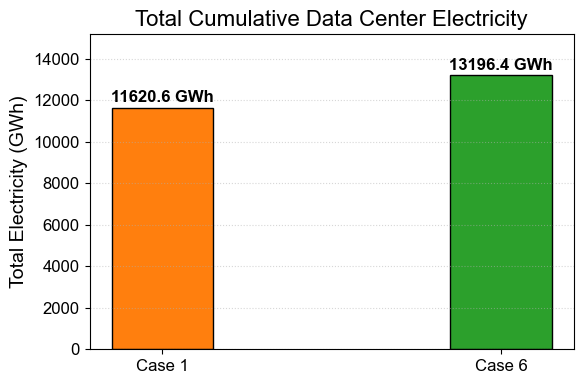

In [ ]:
# using XLSX, DataFrames, PyPlot

# # ==============================================================================
# # 1. STYLE CONFIGURATION
# # ==============================================================================
# style = Dict(
#     "fig_size"      => (6, 4),
#     "bar_width"     => 0.3,
#     "colors"        => ["#ff7f0e", "#2ca02c"], # Blue (Case 1), Orange (Case 6)
#     "line_width"    => 2.5,
#     "font_size"     => 12
# )
# rc("font", size=style["font_size"])

# # ==============================================================================
# # 2. DATA EXTRACTION LOGIC
# # ==============================================================================
# function get_dc_electricity(case_file, baseline_file)
#     if !isfile(case_file); return [], []; end
    
#     xf_case = XLSX.readxlsx(case_file)
    
#     # --- METHOD A: Check Consumption_Summary for Explicit Column ---
#     if "Consumption_Summary" in XLSX.sheetnames(xf_case)
#         df_cons = DataFrame(XLSX.gettable(xf_case["Consumption_Summary"]))
        
#         # Look for columns like "DC_Elec..." or "DataCenter..."
#         dc_cols = [c for c in names(df_cons) if occursin("DC", String(c)) || occursin("Data", String(c))]
        
#         if !isempty(dc_cols)
#             # Found explicit column!
#             println("   -> Found explicit DC column: $(dc_cols[1])")
#             # Filter 2025
#             filter!(row -> row.Year != 2025, df_cons)
#             return df_cons[!, "Year"], coalesce.(df_cons[!, dc_cols[1]], 0.0)
#         end
#     end
    
#     # --- METHOD B: Infer from Generation Difference (Case - NoDC) ---
#     println("   -> No explicit DC column. Calculating (Total Gen - Baseline Gen)...")
    
#     if !isfile(baseline_file); return [], []; end
#     xf_base = XLSX.readxlsx(baseline_file)
    
#     # Load Generation Summaries
#     df_gen_case = DataFrame(XLSX.gettable(xf_case["Generation_Summary"]))
#     df_gen_base = DataFrame(XLSX.gettable(xf_base["Generation_Summary"]))
    
#     # Filter 2025
#     filter!(row -> row.Year != 2025, df_gen_case)
#     filter!(row -> row.Year != 2025, df_gen_base)
    
#     # Sum all generation columns (excluding "Year")
#     function get_total_gen(df)
#         gen_cols = [c for c in names(df) if c != "Year"]
#         total = zeros(nrow(df))
#         for c in gen_cols
#             total .+= coalesce.(df[!, c], 0.0)
#         end
#         return total
#     end
    
#     total_case = get_total_gen(df_gen_case)
#     total_base = get_total_gen(df_gen_base)
    
#     # DC Load = Case Total - Baseline Total
#     # (Assuming other loads are constant)
#     dc_load = total_case .- total_base
    
#     return df_gen_case[!, "Year"], dc_load
# end

# # ==============================================================================
# # 3. LOAD DATA
# # ==============================================================================
# baseline_file = "Results_No_DC.xlsx"
# scenarios = [
#     ("Case 1", "Results_DC_Case_1.xlsx"),
#     ("Case 6", "Results_DC_Case_6.xlsx")
# ]

# data_store = Dict()
# years_list = []

# println("--- Extracting DC Electricity ---")
# for (label, file) in scenarios
#     yrs, vals = get_dc_electricity(file, baseline_file)
#     if !isempty(vals)
#         # Values in Generation_Summary are already in GWh.
#         data_store[label] = (yrs, vals) 
#         global years_list = yrs
#     end
# end

# # ==============================================================================
# # 4. PLOT 1: ANNUAL DC ELECTRICITY (Line Plot)
# # ==============================================================================
# fig1 = figure(figsize=style["fig_size"])
# ax1 = gca()

# for (i, (label, _)) in enumerate(scenarios)
#     if haskey(data_store, label)
#         yrs, vals = data_store[label]
#         ax1.plot(yrs, vals, 
#                  label=label, 
#                  color=style["colors"][i],
#                  linewidth=style["line_width"],
#                  marker="o")
#     end
# end

# title("Annual Data Center Electricity Consumption")
# ylabel("Electricity Consumption (GWh)")
# xlabel("Year")
# grid(linestyle=":", alpha=0.6)
# legend()

# if !isempty(years_list)
#     ax1.set_xticks(years_list)
#     ax1.set_xticklabels(Int.(years_list), rotation=45)
# end

# tight_layout()
# display(fig1)

# # ==============================================================================
# # 5. PLOT 2: TOTAL ELECTRICITY (Bar Plot)
# # ==============================================================================
# fig2 = figure(figsize=style["fig_size"])
# ax2 = gca()

# labels = [s[1] for s in scenarios if haskey(data_store, s[1])]
# totals = [sum(data_store[s[1]][2]) for s in scenarios if haskey(data_store, s[1])]

# x_pos = 0:(length(labels)-1)

# bars = ax2.bar(x_pos, totals, 
#                width=style["bar_width"], 
#                color=style["colors"], 
#                edgecolor="black")

# title("Total Cumulative Data Center Electricity")
# ylabel("Total Electricity (GWh)")
# ax2.set_xticks(x_pos)
# ax2.set_xticklabels(labels)
# grid(axis="y", linestyle=":", alpha=0.5)

# # Add Labels
# for (rect, val) in zip(bars, totals)
#     height = rect.get_height()
#     ax2.text(rect.get_x() + rect.get_width()/2, height + (maximum(totals)*0.01), 
#              string(round(val, digits=1)) * " GWh", 
#              ha="center", va="bottom", fontweight="bold")
# end

# ylim(0, maximum(totals)*1.15)
# tight_layout()
# display(fig2)

In [8]:
# using JLD2, FileIO, PyPlot, XLSX, DataFrames

# # ==============================================================================
# # 1. SETUP
# # ==============================================================================
# excel_path = "Model_Data.xlsx"
# case1_path = "Results_DC_Case_1.jld2"
# case6_path = "Results_DC_Case_6.jld2"

# seasons = Dict(
#     "Winter" => 337:360,
#     "Spring" => 2497:2520,
#     "Summer" => 4681:4704,
#     "Fall"   => 6889:6912
# )
# ordered_seasons = ["Winter", "Spring", "Summer", "Fall"]

# # ==============================================================================
# # 2. DATA LOADING
# # ==============================================================================
# function get_model_parameters(xf)
#     println("   > Reading Model Parameters...")
#     df_scalars = DataFrame(XLSX.gettable(xf["Model_Data"]))
#     get_scal(p) = filter(row -> row.Parameter == p, df_scalars)[1, :Value]
    
#     DC_Cap = Float64(get_scal("DC_Cap"))
#     DC_Active = Float64(get_scal("DC_Active"))
#     y_i = Int(get_scal("y_i"))
#     y_f = Int(get_scal("y_f"))
#     years_list = collect(y_i:y_f)

#     # Sets
#     df_sets = DataFrame(XLSX.gettable(xf["Sets"]))
    
#     # 1. Techs Production
#     t_rows = filter(row -> strip(string(row.set)) == "Tech_el_prod", df_sets)
#     tech_prod_list = String.(strip.(string.(t_rows.element)))
    
#     # 2. Storage Techs
#     st_rows = filter(row -> strip(string(row.set)) == "Tech_st_el", df_sets)
#     if isempty(st_rows)
#         # Fallback if "Tech_st_el" isn't explicitly defined, try "Tech_st"
#         st_rows = filter(row -> strip(string(row.set)) == "Tech_st", df_sets)
#     end
#     tech_st_list = String.(strip.(string.(st_rows.element)))
#     println("   > Storage Techs Found: $tech_st_list")

#     # Factors & Profiles
#     df_tech = DataFrame(XLSX.gettable(xf["Tech_Data"]))
#     # SCALED: Convert Gallons to MMGal
#     W_Cons = Dict(uppercase(string(row.Technology)) => Float64(row.W_Cons) * 1e-6 for row in eachrow(df_tech))

#     df_emi = DataFrame(XLSX.gettable(xf["Annual_emi"]))
#     col_names = names(df_emi)
#     target_col = nothing
#     for c in col_names; if lowercase(c) == "w_con_grid"; target_col = Symbol(c); break; end; end
    
#     W_grid_factor = 0.0
#     if target_col !== nothing
#         row_2030 = filter(row -> row.Year == 2030, df_emi)
#         # SCALED: Convert Gallons to MMGal
#         if !isempty(row_2030); W_grid_factor = Float64(row_2030[1, target_col]) * 1e-6; end
#     end

#     df_pue = DataFrame(XLSX.gettable(xf["WUE_PUE_hourly"]))
#     # SCALED: Convert L/kWh directly to MMGal/MWh
#     unit_conv = 264.172 * 1e-6
#     prof_c1 = Dict(); prof_c6 = Dict()
#     for row in eachrow(df_pue)
#         h = Int(row.Hour_Sequence)
#         prof_c1[h] = (PUE = Float64(row.PUE_Case1), WUE = Float64(row.WUE_Case1) * unit_conv)
#         prof_c6[h] = (PUE = Float64(row.PUE_Case6), WUE = Float64(row.WUE_Case6) * unit_conv)
#     end

#     df_dc = DataFrame(XLSX.gettable(xf["DC_Profile_MV"]))
#     dc_shape = Dict(row.hours => row[Symbol("2030")] for row in eachrow(df_dc))

#     df_el = DataFrame(XLSX.gettable(xf["Electricity"]))
#     base_shape = Dict(row.hours => row[Symbol("2030")] for row in eachrow(df_el))

#     return (years_list, tech_prod_list, tech_st_list, W_grid_factor, W_Cons, 
#             prof_c1, prof_c6, dc_shape, base_shape, DC_Cap, DC_Active)
# end

# function rehydrate_variables(jld_path, years_list, tech_list, st_list)
#     println("   > Loading JLD2: $jld_path")
#     raw = load(jld_path, "results")
    
#     # Grid
#     Pg_clean = Dict{Tuple{Int,Int}, Float64}()
#     for (k, v) in raw["P_g"]
#         if k isa CartesianIndex; Pg_clean[(k[1], years_list[k[2]])] = v
#         elseif k isa Tuple; Pg_clean[k] = v; end
#     end

#     # Tech Production
#     Pp_clean = Dict{Tuple{String,Int,Int}, Float64}()
#     for (k, v) in raw["P_p"]
#         if k isa CartesianIndex
#             if k[1] <= length(tech_list)
#                 Pp_clean[(tech_list[k[1]], k[2], years_list[k[3]])] = v
#             end
#         elseif k isa Tuple; Pp_clean[k] = v; end
#     end

#     # Storage: P_ch (Charge) and P_dis (Discharge)
#     Pch_clean = Dict{Tuple{String,Int,Int}, Float64}()
#     Pdis_clean = Dict{Tuple{String,Int,Int}, Float64}()
    
#     if haskey(raw, "P_ch") && raw["P_ch"] !== nothing
#         for (k, v) in raw["P_ch"]
#             if k isa CartesianIndex
#                  if k[1] <= length(st_list)
#                     Pch_clean[(st_list[k[1]], k[2], years_list[k[3]])] = v
#                  end
#             elseif k isa Tuple; Pch_clean[k] = v; end
#         end
#     end
    
#     if haskey(raw, "P_dis") && raw["P_dis"] !== nothing
#         for (k, v) in raw["P_dis"]
#              if k isa CartesianIndex
#                  if k[1] <= length(st_list)
#                     Pdis_clean[(st_list[k[1]], k[2], years_list[k[3]])] = v
#                  end
#             elseif k isa Tuple; Pdis_clean[k] = v; end
#         end
#     end

#     return Pg_clean, Pp_clean, Pch_clean, Pdis_clean
# end

# # ==============================================================================
# # 3. PLOTTING WITH STORAGE & CURTAILMENT
# # ==============================================================================

# function plot_curtailment_dashboard(Pg, Pp, Pch, Pdis, profiles, case_name, 
#                                  W_grid_factor, W_Cons, 
#                                  dc_shape, base_shape, DC_Cap, DC_Active)
    
#     fig, axs = subplots(4, 2, figsize=(15, 14), constrained_layout=true)
#     fig.suptitle("Supply, Storage & Curtailment (2030) - $case_name", fontsize=16)

#     for (idx, s_name) in enumerate(ordered_seasons)
#         range = seasons[s_name]
#         hours = collect(range)
#         x_axis = 1:24
        
#         # --- A. ELECTRICITY DATA ---
        
#         # 1. Supply Side (Generators + Storage DISCHARGE)
#         techs = unique([k[1] for k in keys(Pp)])
#         gen_arrays = Dict()
#         for t in techs; gen_arrays[t] = [get(Pp, (t, h, 2030), 0.0) for h in hours]; end
        
#         grid_import = [get(Pg, (h, 2030), 0.0) for h in hours]
        
#         # Storage Discharge (Acts as Supply)
#         st_techs = unique([k[1] for k in keys(Pdis)])
#         dis_arrays = Dict()
#         for t in st_techs; dis_arrays[t] = [get(Pdis, (t, h, 2030), 0.0) for h in hours]; end

#         # 2. Demand Side (Load + Storage CHARGE)
#         base_load = [base_shape[h] for h in hours]
#         dc_load = [DC_Active * dc_shape[h] * DC_Cap * profiles[h].PUE for h in hours]
        
#         # Storage Charge (Acts as Demand)
#         ch_arrays = Dict()
#         st_charge_total = zeros(24)
#         for t in st_techs
#              arr = [get(Pch, (t, h, 2030), 0.0) for h in hours]
#              ch_arrays[t] = arr
#              st_charge_total .+= arr
#         end
        
#         load_demand = base_load .+ dc_load
#         total_consumption = load_demand .+ st_charge_total

#         # --- B. PLOT ELECTRICITY (Left) ---
#         ax_el = axs[idx, 1]
        
#         # Build Stack
#         labels = String[]
#         stack_data = Vector{Vector{Float64}}()
        
#         # 1. Grid
#         if sum(grid_import) > 0.1
#             push!(labels, "Grid")
#             push!(stack_data, grid_import)
#         end
#         # 2. Renewables/Gen
#         for t in techs
#             if sum(gen_arrays[t]) > 0.1
#                 push!(labels, t)
#                 push!(stack_data, gen_arrays[t])
#             end
#         end
#         # 3. Storage Discharge
#         for t in st_techs
#             if sum(dis_arrays[t]) > 0.1
#                 push!(labels, "$t (Discharge)")
#                 push!(stack_data, dis_arrays[t])
#             end
#         end
        
#         if !isempty(stack_data)
#             ax_el.stackplot(x_axis, stack_data..., labels=labels, alpha=0.6)
#         end
        
#         # Plot Lines
#         # 1. Base Load (Black Dotted)
#         ax_el.plot(x_axis, base_load, color="black", linestyle="--", linewidth=1.5, alpha=0.7, label="Base Load")
        
#         # Red = Actual Load (Base + DC)
#         ax_el.plot(x_axis, load_demand, color="red", linewidth=2, label="Load (Base+DC)")
        
#         # Purple Dotted = Load + Charging (The effective consumption limit)
#         if sum(st_charge_total) > 0.1
#             ax_el.plot(x_axis, total_consumption, color="purple", linestyle="--", linewidth=2, label="Load + Charging")
#         end
        
#         ax_el.set_title("$s_name - Supply & Storage", fontsize=11)
#         ax_el.set_ylabel("MW")
#         ax_el.set_xlim(1, 24)
#         if idx == 1; ax_el.legend(loc="upper left", fontsize=8, bbox_to_anchor=(1, 1)); end

#         # --- C. PLOT WATER (Right) ---
#         tech_water = zeros(24)
#         for t in techs
#             t_key = uppercase(t)
#             factor = get(W_Cons, t_key, 0.0)
#             tech_water .+= gen_arrays[t] .* factor
#         end
#         dc_water = [ (DC_Active * dc_shape[h] * DC_Cap * profiles[h].PUE) * profiles[h].WUE for h in hours ]
#         grid_water = grid_import .* W_grid_factor

#         ax_w = axs[idx, 2]
#         w_stack = [grid_water, tech_water, dc_water]
#         w_labels = ["Grid Indirect", "Tech Direct", "DC Direct"]
#         w_colors = ["tab:gray", "tab:blue", "tab:cyan"]
#         ax_w.stackplot(x_axis, w_stack..., labels=w_labels, colors=w_colors, alpha=0.7)
#         ax_w.set_title("$s_name - Water", fontsize=11)
#         # UPDATED: Y-axis label changed to MMGal
#         ax_w.set_ylabel("MMGal") 
#         ax_w.set_xlim(1, 24)
#         if idx == 1; ax_w.legend(loc="upper left", fontsize=8); end
#     end
    
#     for ax in axs[4, :]; ax.set_xlabel("Hour of Day"); end
#     return fig
# end

# # ==============================================================================
# # 4. EXECUTE
# # ==============================================================================
# println("Starting Analysis...")
# xf = XLSX.readxlsx(excel_path)
# (years, tech_list, st_list, W_grid, W_Cons, prof_c1, prof_c6, dc_shp, base_shp, dc_cap, dc_act) = get_model_parameters(xf)

# println("\n--- Processing Case 1 ---")
# Pg_1, Pp_1, Pch_1, Pdis_1 = rehydrate_variables(case1_path, years, tech_list, st_list)
# fig1 = plot_curtailment_dashboard(Pg_1, Pp_1, Pch_1, Pdis_1, prof_c1, "Case 1", W_grid, W_Cons, dc_shp, base_shp, dc_cap, dc_act)
# display(fig1)

# println("\n--- Processing Case 6 ---")
# Pg_6, Pp_6, Pch_6, Pdis_6 = rehydrate_variables(case6_path, years, tech_list, st_list)
# fig6 = plot_curtailment_dashboard(Pg_6, Pp_6, Pch_6, Pdis_6, prof_c6, "Case 6", W_grid, W_Cons, dc_shp, base_shp, dc_cap, dc_act)
# display(fig6)

Starting Annual Analysis...
   > Reading Model Parameters from Excel...

--- Processing ASE + Evap. Cooling ---
   > Loading JLD2: Results_DC_Case_1.jld2
Saved Annual_Water_Bar_Case1.png

--- Processing ASE + Air Chillers ---
   > Loading JLD2: Results_DC_Case_6.jld2
Saved Annual_Water_Bar_Case6.png

Done!


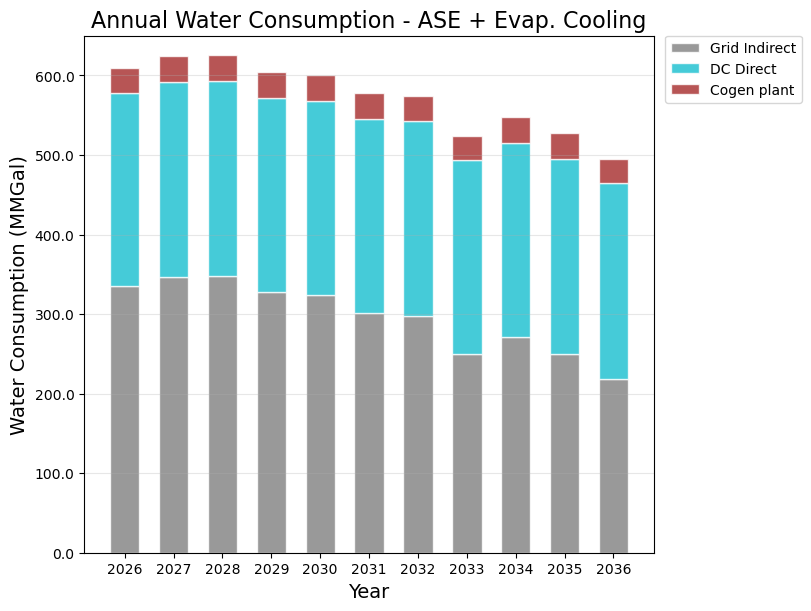

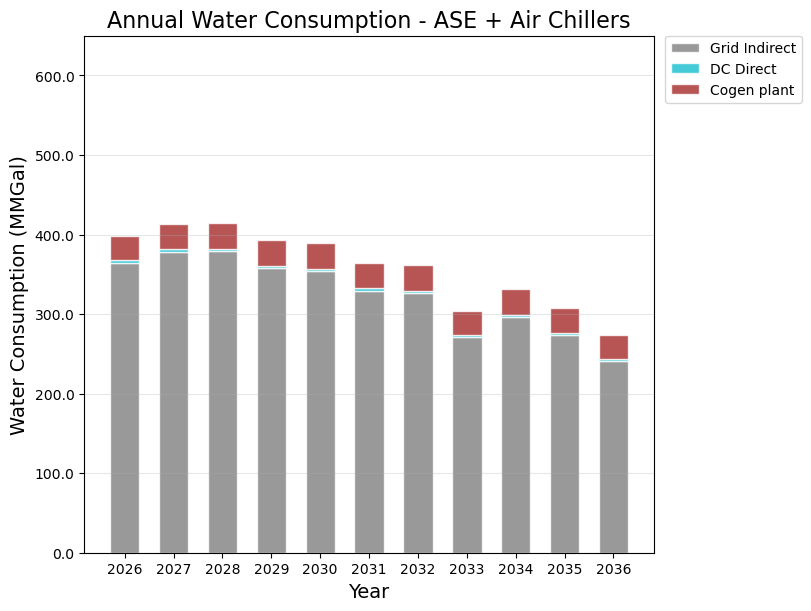

In [3]:
using JLD2, FileIO, PyPlot, XLSX, DataFrames

# ==============================================================================
# 1. SETUP & PATHS
# ==============================================================================
excel_path = "Model_Data.xlsx"
case1_path = "Results_DC_Case_1.jld2"
case6_path = "Results_DC_Case_6.jld2"

# ==============================================================================
# 2. DATA LOADING FUNCTIONS (ROBUST & COMPLETE)
# ==============================================================================

function get_model_parameters(xf)
    println("   > Reading Model Parameters from Excel...")
    
    # A. Scalars
    df_scalars = DataFrame(XLSX.gettable(xf["Model_Data"]))
    get_scal(p) = filter(row -> row.Parameter == p, df_scalars)[1, :Value]
    
    DC_Cap = Float64(get_scal("DC_Cap"))
    DC_Active = Float64(get_scal("DC_Active"))
    y_i = Int(get_scal("y_i"))
    y_f = Int(get_scal("y_f"))
    years_list = collect(y_i:y_f)

    # B. Sets (Map Tech Indices -> Names)
    df_sets = DataFrame(XLSX.gettable(xf["Sets"]))
    tech_prod_rows = filter(row -> strip(string(row.set)) == "Tech_el_prod", df_sets)
    tech_prod_list = String.(strip.(string.(tech_prod_rows.element)))

    # C. Grid Water Factors (ALL YEARS)
    df_emi = DataFrame(XLSX.gettable(xf["Annual_emi"]))
    
    # Robust Column Search
    col_names = names(df_emi)
    target_col = nothing
    for c in col_names
        if lowercase(c) == "w_con_grid"
            target_col = Symbol(c)
            break
        end
    end
    
    W_grid_yearly = Dict{Int, Float64}()
    if target_col === nothing
        println("   ⚠️ WARNING: Column 'W_con_grid' not found. Assuming 0.0 for all years.")
        for y in years_list; W_grid_yearly[y] = 0.0; end
    else
        for row in eachrow(df_emi)
            y = Int(row.Year)
            val = row[target_col]
            # SCALED: Convert Gallons to MMGal
            W_grid_yearly[y] = ismissing(val) ? 0.0 : Float64(val) * 1e-6
        end
    end

    # D. Tech Water Factors
    df_tech = DataFrame(XLSX.gettable(xf["Tech_Data"]))
    # SCALED: Convert Gallons to MMGal
    W_Cons = Dict(uppercase(string(row.Technology)) => Float64(row.W_Cons) * 1e-6 for row in eachrow(df_tech))

    # E. Profiles (PUE/WUE)
    df_pue = DataFrame(XLSX.gettable(xf["WUE_PUE_hourly"]))
    # SCALED: Convert L/kWh directly to MMGal/MWh
    unit_conv = 264.172 * 1e-6 
    prof_c1 = Dict(); prof_c6 = Dict()
    for row in eachrow(df_pue)
        h = Int(row.Hour_Sequence)
        prof_c1[h] = (PUE = Float64(row.PUE_Case1), WUE = Float64(row.WUE_Case1) * unit_conv)
        prof_c6[h] = (PUE = Float64(row.PUE_Case6), WUE = Float64(row.WUE_Case6) * unit_conv)
    end

    # F. Load Shapes (Yearly Columns)
    df_dc = DataFrame(XLSX.gettable(xf["DC_Profile_MV"]))
    # Map Year -> Hourly Profile
    dc_shape_yearly = Dict{Int, Vector{Float64}}()
    
    # Check available columns in DC_Profile_MV
    dc_cols = names(df_dc)
    
    for y in years_list
        y_sym = Symbol(string(y))
        if String(y_sym) in dc_cols
            # Read column for this year
            dc_shape_yearly[y] = df_dc[!, y_sym]
        else
            # Fallback: Try to find a 'Value' column or use first data column
             if "2030" in dc_cols
                dc_shape_yearly[y] = df_dc[!, Symbol("2030")]
             else
                 dc_shape_yearly[y] = df_dc[!, 2]
             end
        end
    end

    return (years_list, tech_prod_list, W_grid_yearly, W_Cons, 
            prof_c1, prof_c6, dc_shape_yearly, DC_Cap, DC_Active)
end

function rehydrate_variables(jld_path, years_list, tech_list)
    println("   > Loading JLD2: $jld_path")
    raw = load(jld_path, "results")
    
    Pg_raw = raw["P_g"]
    Pg_clean = Dict{Tuple{Int,Int}, Float64}()
    
    for (k, v) in Pg_raw
        if k isa CartesianIndex
            h, y_idx = k[1], k[2]
            Pg_clean[(h, years_list[y_idx])] = v
        elseif k isa Tuple
            Pg_clean[k] = v
        end
    end

    Pp_raw = raw["P_p"]
    Pp_clean = Dict{Tuple{String,Int,Int}, Float64}()
    
    for (k, v) in Pp_raw
        if k isa CartesianIndex
            t_idx, h, y_idx = k[1], k[2], k[3]
            t_name = tech_list[t_idx] 
            y_real = years_list[y_idx]
            Pp_clean[(t_name, h, y_real)] = v
        elseif k isa Tuple
            Pp_clean[k] = v
        end
    end
    
    return Pg_clean, Pp_clean
end

# ==============================================================================
# 3. ANALYSIS & PLOTTING
# ==============================================================================

function plot_annual_water_bar(Pg, Pp, profiles, case_name, years,
                               W_grid_yearly, W_Cons, 
                               dc_shape_yearly, DC_Cap, DC_Active, TECH_COLORS; y_max=nothing)
    
    # 1. Filter Years (Exclude 2025)
    plot_years = filter(y -> y != 2025, years)
    
    # 2. Identify Active Techs across all years (FILTER BY WATER CONSUMPTION)
    all_techs = unique([k[1] for k in keys(Pp)])
    active_techs = []
    for t in all_techs
        total_gen = sum([get(Pp, (t, h, y), 0.0) for h in 1:8760 for y in plot_years])
        factor = get(W_Cons, uppercase(t), 0.0)
        
        total_water = total_gen * factor
        
        # Only add to the plot if it actually consumes water
        if total_water > 1e-6 
            push!(active_techs, t)
        end
    end
    
    # 3. Calculate Annual Totals
    annual_data = Dict{Int, Dict{String, Float64}}()
    
    for y in plot_years
        annual_data[y] = Dict{String, Float64}()
        
        # A. Grid Indirect
        grid_mwh = sum([get(Pg, (h, y), 0.0) for h in 1:8760])
        grid_water = grid_mwh * get(W_grid_yearly, y, 0.0)
        annual_data[y]["Grid Indirect"] = grid_water
        
        # B. DC Direct
        shape = dc_shape_yearly[y]
        dc_water = 0.0
        for h in 1:8760
             load_mw = DC_Active * shape[h] * DC_Cap * profiles[h].PUE
             dc_water += load_mw * profiles[h].WUE
        end
        annual_data[y]["DC Direct"] = dc_water
        
        # C. Tech Direct (Per Tech)
        for t in active_techs
            gen_mwh = sum([get(Pp, (t, h, y), 0.0) for h in 1:8760])
            factor = get(W_Cons, uppercase(t), 0.0)
            
            # Change "cg_el" to "Cogen plant" for display
            display_name = (t == "cg_el") ? "Cogen plant" : t
            annual_data[y][display_name] = gen_mwh * factor
        end
    end
    
    # 4. Prepare Plot Data
    categories = ["Grid Indirect", "DC Direct"]
    for t in active_techs
        display_name = (t == "cg_el") ? "Cogen plant" : t
        push!(categories, display_name)
    end
    
    n_years = length(plot_years)
    n_cats = length(categories)
    
    data_matrix = zeros(n_years, n_cats)
    for (i, y) in enumerate(plot_years)
        for (j, cat) in enumerate(categories)
            data_matrix[i, j] = get(annual_data[y], cat, 0.0)
        end
    end
    
    # 5. Plotting
    fig, ax = subplots(figsize=(8, 6), constrained_layout=true)
    
    bottoms = zeros(n_years)
    
    for j in 1:n_cats
        cat_name = categories[j]
        vals = data_matrix[:, j]
        
        c = get(TECH_COLORS, cat_name, "black") 
        
        ax.bar(string.(plot_years), vals, bottom=bottoms, label=cat_name, color=c, alpha=0.8, edgecolor="white", width=0.6)
        bottoms .+= vals
    end
    
    ax.set_title("Annual Water Consumption - $case_name", fontsize=16)
    
    ax.set_ylabel("Water Consumption (MMGal)", fontsize=14)
    ax.set_xlabel("Year", fontsize=14)
    
    # --- ADD THIS NEW BLOCK HERE ---
    if y_max !== nothing
        ax.set_ylim(0, y_max)
    end

    ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.1f}"))
    
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    ax.grid(axis="y", alpha=0.3)

    return fig
end

# ==============================================================================
# 4. EXECUTION
# ==============================================================================

println("Starting Annual Analysis...")

# 1. Read Excel
xf = XLSX.readxlsx(excel_path)
(years, techs, W_grid, W_Cons, prof_c1, prof_c6, dc_shp, dc_cap, dc_act) = get_model_parameters(xf)

# --- BUILD CONSISTENT COLOR MAP ---
TECH_COLORS = Dict{String, Any}()
TECH_COLORS["Grid Indirect"] = "gray"
TECH_COLORS["DC Direct"] = "tab:cyan"

semantic_colors = Dict(
    "nu" => "green", "nuclear" => "green",
    "pv" => "gold", "solar" => "gold",
    "pv_ro" => "pink", 
    "cg_el" => "brown", "ng" => "brown", "Cogen plant" => "brown",
    "wt" => "orange", "wind" => "orange",
    "Grid" => "gray",
    "li_ion (Discharge)" => "steelblue",
    "bb (Discharge)" => "steelblue",
    "li_ion (Charge)" => "silver",
    "bb (Charge)" => "silver"
)

cmap = get_cmap("tab20").colors
c_idx = 1

for t in techs
    display_name = (t == "cg_el") ? "Cogen plant" : t
    
    if haskey(semantic_colors, display_name)
        TECH_COLORS[display_name] = semantic_colors[display_name]
    elseif haskey(semantic_colors, t)
        TECH_COLORS[display_name] = semantic_colors[t]
    else
        TECH_COLORS[display_name] = cmap[mod1(c_idx, 20)]
        c_idx += 1
    end
end
# ----------------------------------

# 2. Process Case 1
println("\n--- Processing ASE + Evap. Cooling ---")
Pg_1, Pp_1 = rehydrate_variables(case1_path, years, techs)
fig1 = plot_annual_water_bar(Pg_1, Pp_1, prof_c1, "ASE + Evap. Cooling", 
                             years, W_grid, W_Cons, dc_shp, dc_cap, dc_act, TECH_COLORS, y_max=650)
display(fig1)
# savefig("Annual_Water_Bar_Case1.png")
println("Saved Annual_Water_Bar_Case1.png")

# 3. Process Case 6
println("\n--- Processing ASE + Air Chillers ---")
Pg_6, Pp_6 = rehydrate_variables(case6_path, years, techs)
fig6 = plot_annual_water_bar(Pg_6, Pp_6, prof_c6, "ASE + Air Chillers", 
                             years, W_grid, W_Cons, dc_shp, dc_cap, dc_act, TECH_COLORS, y_max=650)
display(fig6)
# savefig("Annual_Water_Bar_Case6.png")
println("Saved Annual_Water_Bar_Case6.png")

println("\nDone!")

Starting Annual Electricity Analysis...
   > Reading Model Parameters from Excel...

--- Processing ASE + Evap. Cooling ---
   > Loading JLD2: Results_DC_Case_1.jld2
Saved Annual_Electricity_Bar_Case1.png

--- Processing ASE + Air Chillers ---
   > Loading JLD2: Results_DC_Case_6.jld2
Saved Annual_Electricity_Bar_Case6.png

Done!


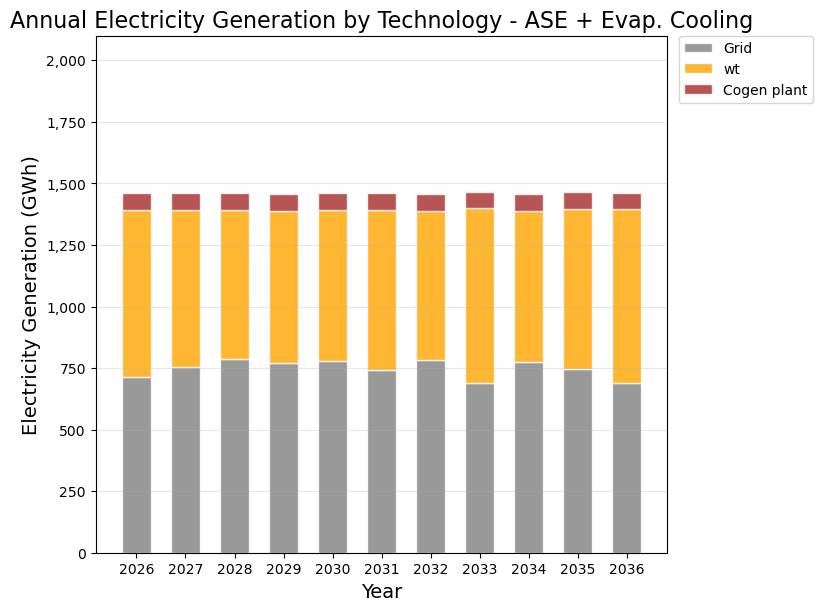

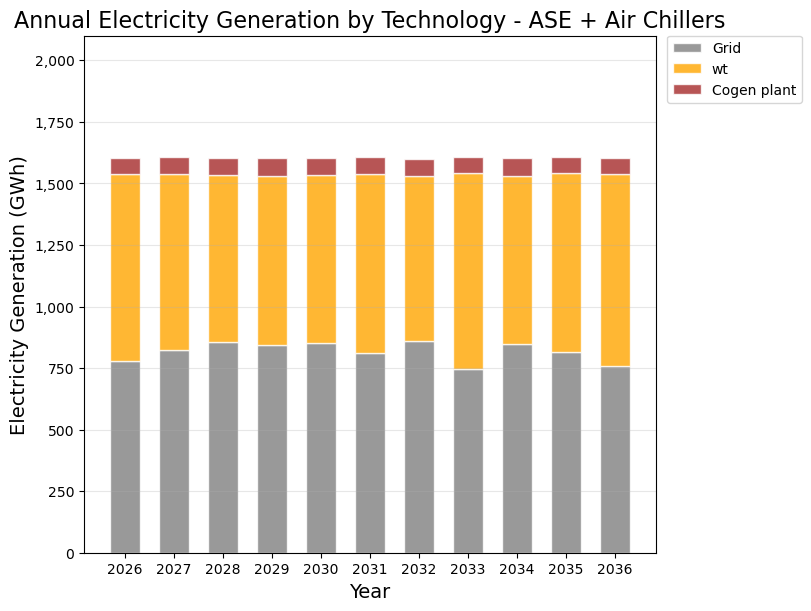

In [2]:
using JLD2, FileIO, PyPlot, XLSX, DataFrames

# ==============================================================================
# 1. SETUP & PATHS
# ==============================================================================
excel_path = "Model_Data.xlsx"
case1_path = "Results_DC_Case_1.jld2"
case6_path = "Results_DC_Case_6.jld2"


# ==============================================================================
# 2. DATA LOADING FUNCTIONS (ROBUST & COMPLETE)
# ==============================================================================

function get_model_parameters(xf)
    println("   > Reading Model Parameters from Excel...")
    
    # A. Scalars
    df_scalars = DataFrame(XLSX.gettable(xf["Model_Data"]))
    get_scal(p) = filter(row -> row.Parameter == p, df_scalars)[1, :Value]
    
    y_i = Int(get_scal("y_i"))
    y_f = Int(get_scal("y_f"))
    years_list = collect(y_i:y_f)

    # B. Sets (Map Tech Indices -> Names)
    df_sets = DataFrame(XLSX.gettable(xf["Sets"]))
    tech_prod_rows = filter(row -> strip(string(row.set)) == "Tech_el_prod", df_sets)
    tech_prod_list = String.(strip.(string.(tech_prod_rows.element)))

    return (years_list, tech_prod_list)
end

function rehydrate_variables(jld_path, years_list, tech_list)
    println("   > Loading JLD2: $jld_path")
    raw = load(jld_path, "results")
    
    Pg_raw = raw["P_g"]
    Pg_clean = Dict{Tuple{Int,Int}, Float64}()
    
    for (k, v) in Pg_raw
        if k isa CartesianIndex
            h, y_idx = k[1], k[2]
            Pg_clean[(h, years_list[y_idx])] = v
        elseif k isa Tuple
            Pg_clean[k] = v
        end
    end

    Pp_raw = raw["P_p"]
    Pp_clean = Dict{Tuple{String,Int,Int}, Float64}()
    
    for (k, v) in Pp_raw
        if k isa CartesianIndex
            t_idx, h, y_idx = k[1], k[2], k[3]
            t_name = tech_list[t_idx] 
            y_real = years_list[y_idx]
            Pp_clean[(t_name, h, y_real)] = v
        elseif k isa Tuple
            Pp_clean[k] = v
        end
    end
    
    return Pg_clean, Pp_clean
end

# ==============================================================================
# 3. ANALYSIS & PLOTTING
# ==============================================================================

function plot_annual_electricity_bar(Pg, Pp, case_name, years, TECH_COLORS; y_max=nothing) 
    
    # 1. Filter Years (Exclude 2025)
    plot_years = filter(y -> y != 2025, years)
    
    # 2. Identify Active Techs across all years
    all_techs = unique([k[1] for k in keys(Pp)])
    
    # Filter to only techs that actually produce something > 1 GWh total
    active_techs = String[]
    for t in all_techs
        total_gen_gwh = sum([get(Pp, (t, h, y), 0.0) for h in 1:8760 for y in plot_years]) / 1000.0
        if total_gen_gwh > 1.0
            push!(active_techs, t)
        end
    end
    
    # 3. Calculate Annual Totals
    # Structure: Dict(Year => Dict(Category => Value_in_GWh))
    annual_data = Dict{Int, Dict{String, Float64}}()
    
    for y in plot_years
        annual_data[y] = Dict{String, Float64}()
        
        # A. Grid (Convert MWh to GWh)
        grid_gwh = sum([get(Pg, (h, y), 0.0) for h in 1:8760]) / 1000.0
        annual_data[y]["Grid"] = grid_gwh
        
        # B. Tech Direct (Per Tech, Convert MWh to GWh)
        for t in active_techs
            gen_gwh = sum([get(Pp, (t, h, y), 0.0) for h in 1:8760]) / 1000.0
            # Change "cg_el" to "Cogen plant" for display
            display_name = (t == "cg_el") ? "Cogen plant" : t
            annual_data[y][display_name] = gen_gwh
        end
    end
    
    # 4. Prepare Plot Data
    categories = ["Grid"]
    for t in active_techs
        display_name = (t == "cg_el") ? "Cogen plant" : t
        push!(categories, display_name)
    end
    
    # Build Matrix for Bar Plot
    # Rows: Years, Cols: Categories
    n_years = length(plot_years)
    n_cats = length(categories)
    
    data_matrix = zeros(n_years, n_cats)
    for (i, y) in enumerate(plot_years)
        for (j, cat) in enumerate(categories)
            data_matrix[i, j] = get(annual_data[y], cat, 0.0)
        end
    end
    
    # 5. Plotting
    fig, ax = subplots(figsize=(8, 6), constrained_layout=true)
    
    # Create Stacked Bars
    bottoms = zeros(n_years)
    
    for j in 1:n_cats
        cat_name = categories[j]
        vals = data_matrix[:, j]
        
        # Retrieve consistent color from the dictionary
        c = get(TECH_COLORS, cat_name, "black") 
        
        ax.bar(string.(plot_years), vals, bottom=bottoms, label=cat_name, color=c, alpha=0.8, edgecolor="white", width=0.6)
        bottoms .+= vals
    end
    
    ax.set_title("Annual Electricity Generation by Technology - $case_name", fontsize=16)
    
    # Y-axis is now Electricity (GWh)
    ax.set_ylabel("Electricity Generation (GWh)", fontsize=14)
    ax.set_xlabel("Year", fontsize=14)

    # --- ADD THIS NEW BLOCK HERE ---
    if y_max !== nothing
        ax.set_ylim(0, y_max)
    end
    
    # Formatter for thousands without decimals
    ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    ax.grid(axis="y", alpha=0.3)

    return fig
end

# ==============================================================================
# 4. EXECUTION
# ==============================================================================

println("Starting Annual Electricity Analysis...")

# 1. Read Excel
xf = XLSX.readxlsx(excel_path)
(years, techs) = get_model_parameters(xf)

# --- BUILD CONSISTENT COLOR MAP ---
# This ensures that a technology gets the exact same color in every single plot.
TECH_COLORS = Dict{String, Any}()
TECH_COLORS["Grid"] = "gray"

# Standard intuitive colors for common technologies
semantic_colors = Dict(
    "nu" => "green", "nuclear" => "green",
    "pv" => "gold", "solar" => "gold",
    "pv_ro" => "pink", 
    "cg_el" => "brown", "ng" => "brown", "Cogen plant" => "brown",
    "wt" => "orange", "wind" => "orange",
    "Grid" => "gray",
    "li_ion (Discharge)" => "steelblue",
    "bb (Discharge)" => "steelblue",
    "li_ion (Charge)" => "silver",
    "bb (Charge)" => "silver"
)

cmap = get_cmap("tab20").colors
c_idx = 1

for t in techs
    display_name = (t == "cg_el") ? "Cogen plant" : t
    
    if haskey(semantic_colors, display_name)
        TECH_COLORS[display_name] = semantic_colors[display_name]
    elseif haskey(semantic_colors, t)
        TECH_COLORS[display_name] = semantic_colors[t]
    else
        # Assign a generic distinct color from tab20 if it isn't predefined
        TECH_COLORS[display_name] = cmap[mod1(c_idx, 20)]
        c_idx += 1
    end
end
# ----------------------------------

# 2. Process Case 1
println("\n--- Processing ASE + Evap. Cooling ---")
Pg_1, Pp_1 = rehydrate_variables(case1_path, years, techs)
fig1 = plot_annual_electricity_bar(Pg_1, Pp_1, "ASE + Evap. Cooling", years, TECH_COLORS, y_max=2100)
display(fig1)
# savefig("Annual_Electricity_Bar_Case1.png")
println("Saved Annual_Electricity_Bar_Case1.png")

# 3. Process Case 6
println("\n--- Processing ASE + Air Chillers ---")
Pg_6, Pp_6 = rehydrate_variables(case6_path, years, techs)
fig6 = plot_annual_electricity_bar(Pg_6, Pp_6, "ASE + Air Chillers", years, TECH_COLORS, y_max=2100)
display(fig6)
# savefig("Annual_Electricity_Bar_Case6.png")
println("Saved Annual_Electricity_Bar_Case6.png")

println("\nDone!")

Starting Weekly Analysis...
   > Reading Model Parameters...

--- Generating Plots for ASE + Evap. Cooling ---

--- Generating Plots for ASE + Air Chillers ---

All plots processed successfully.


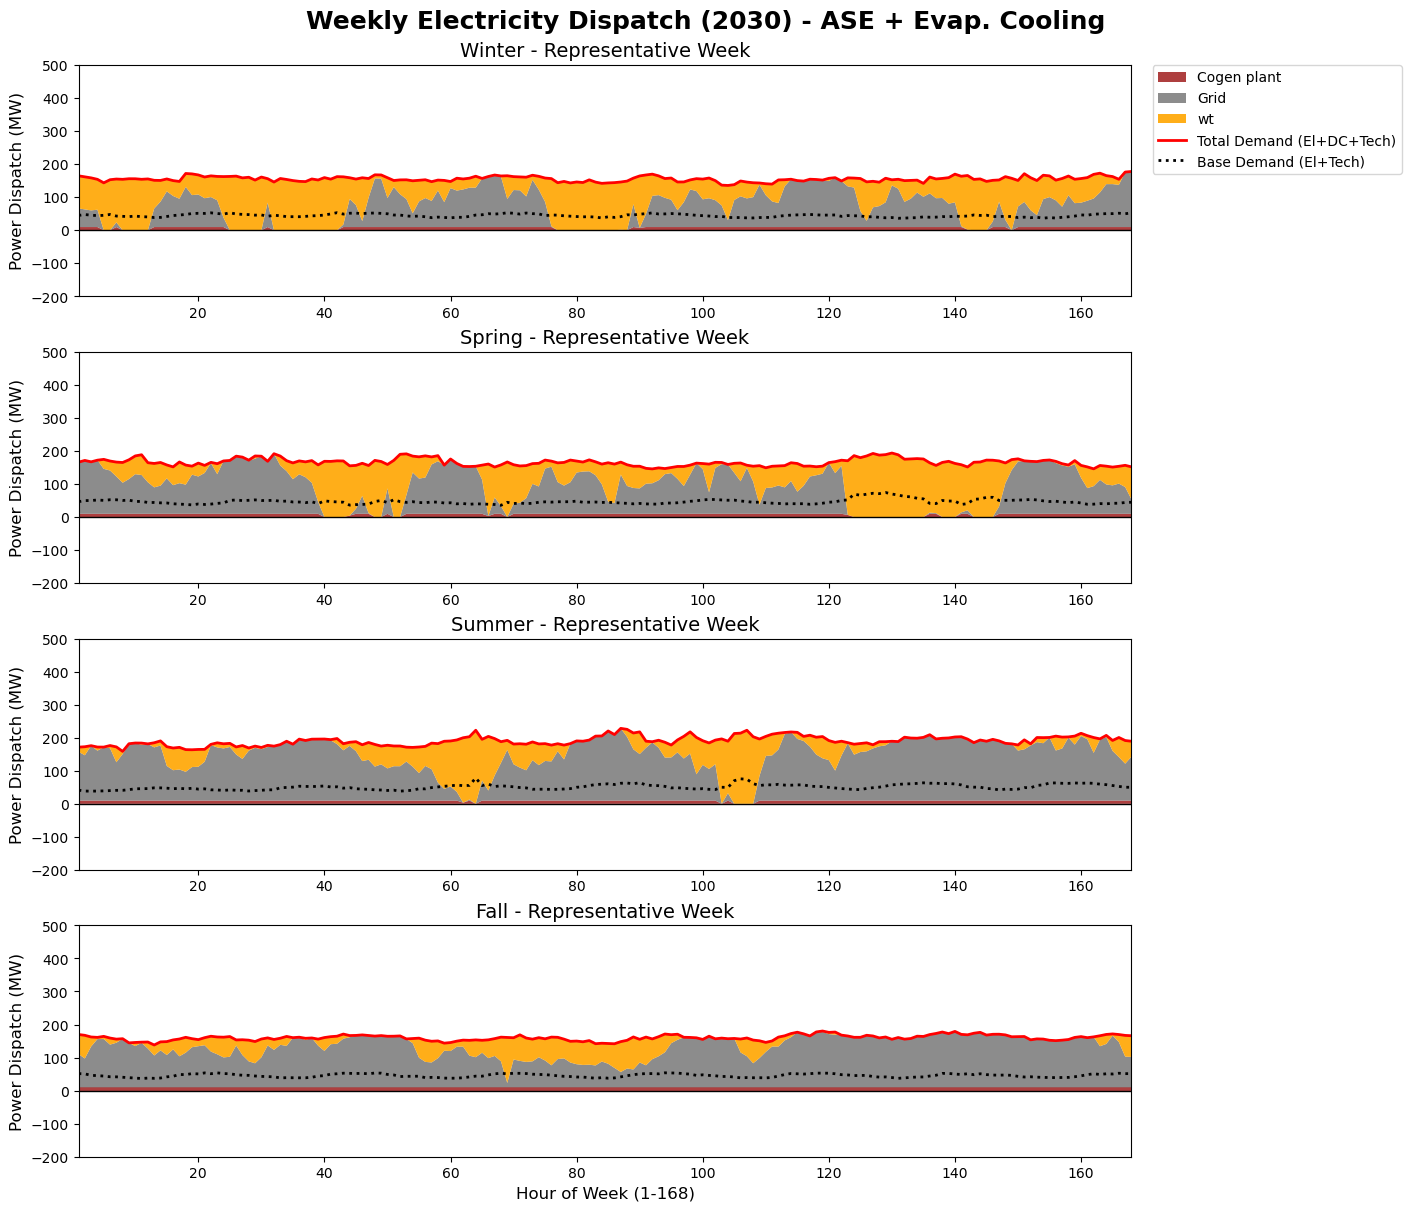

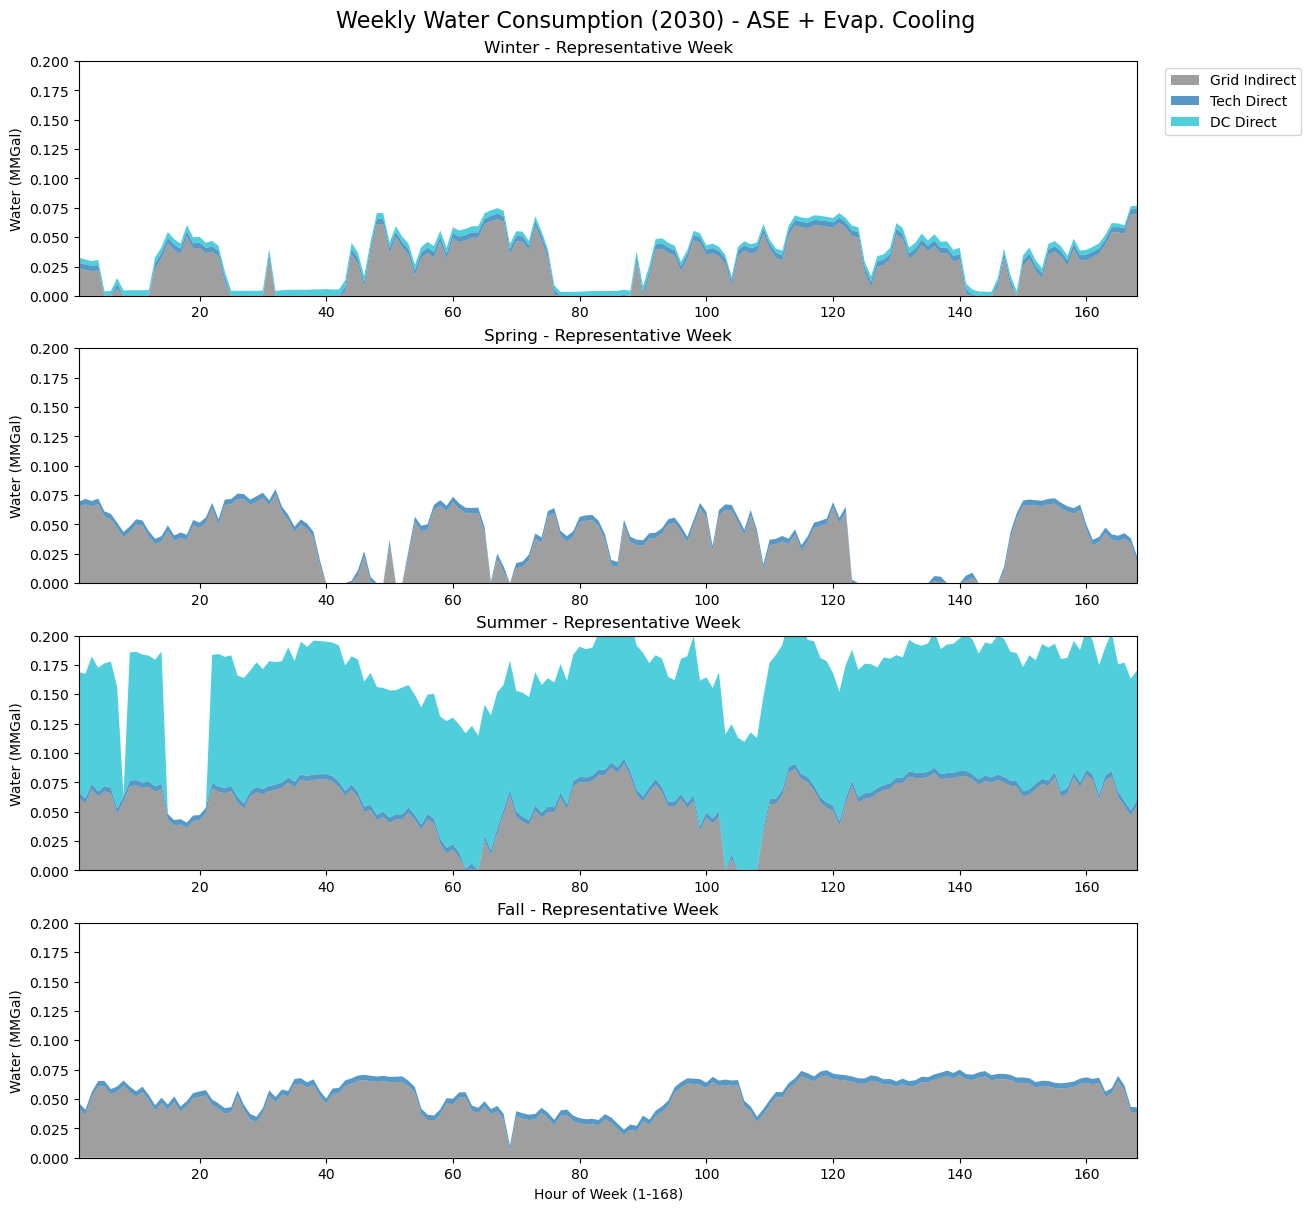

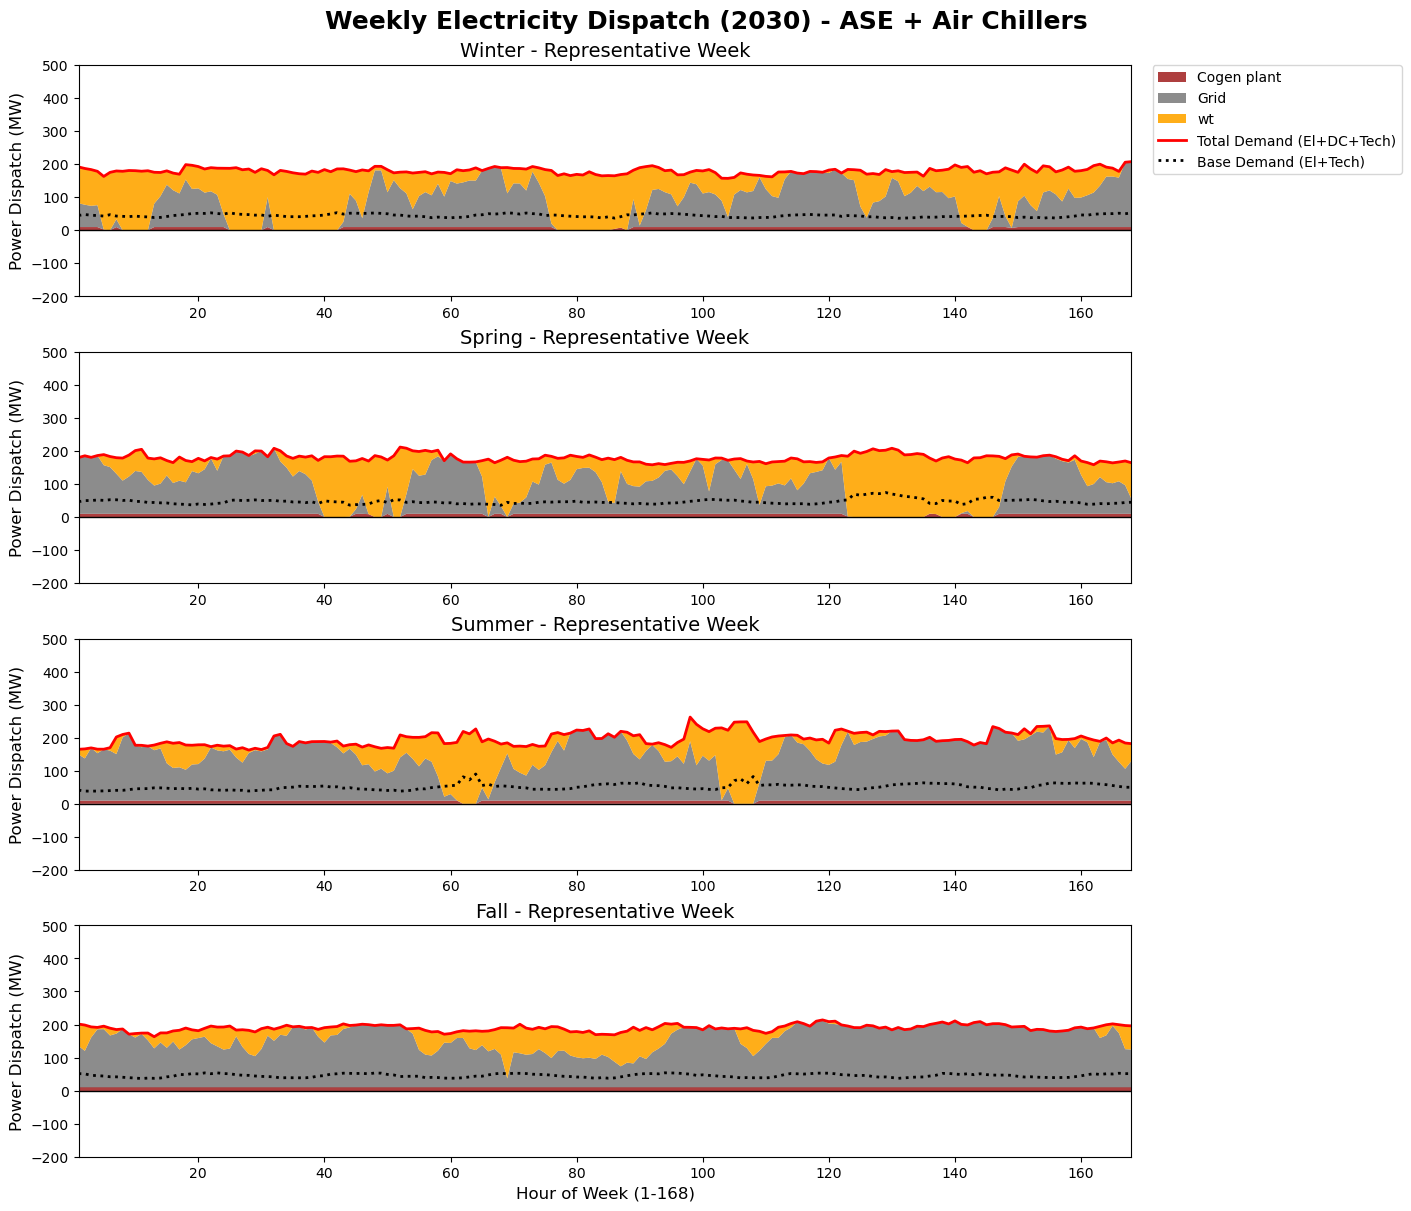

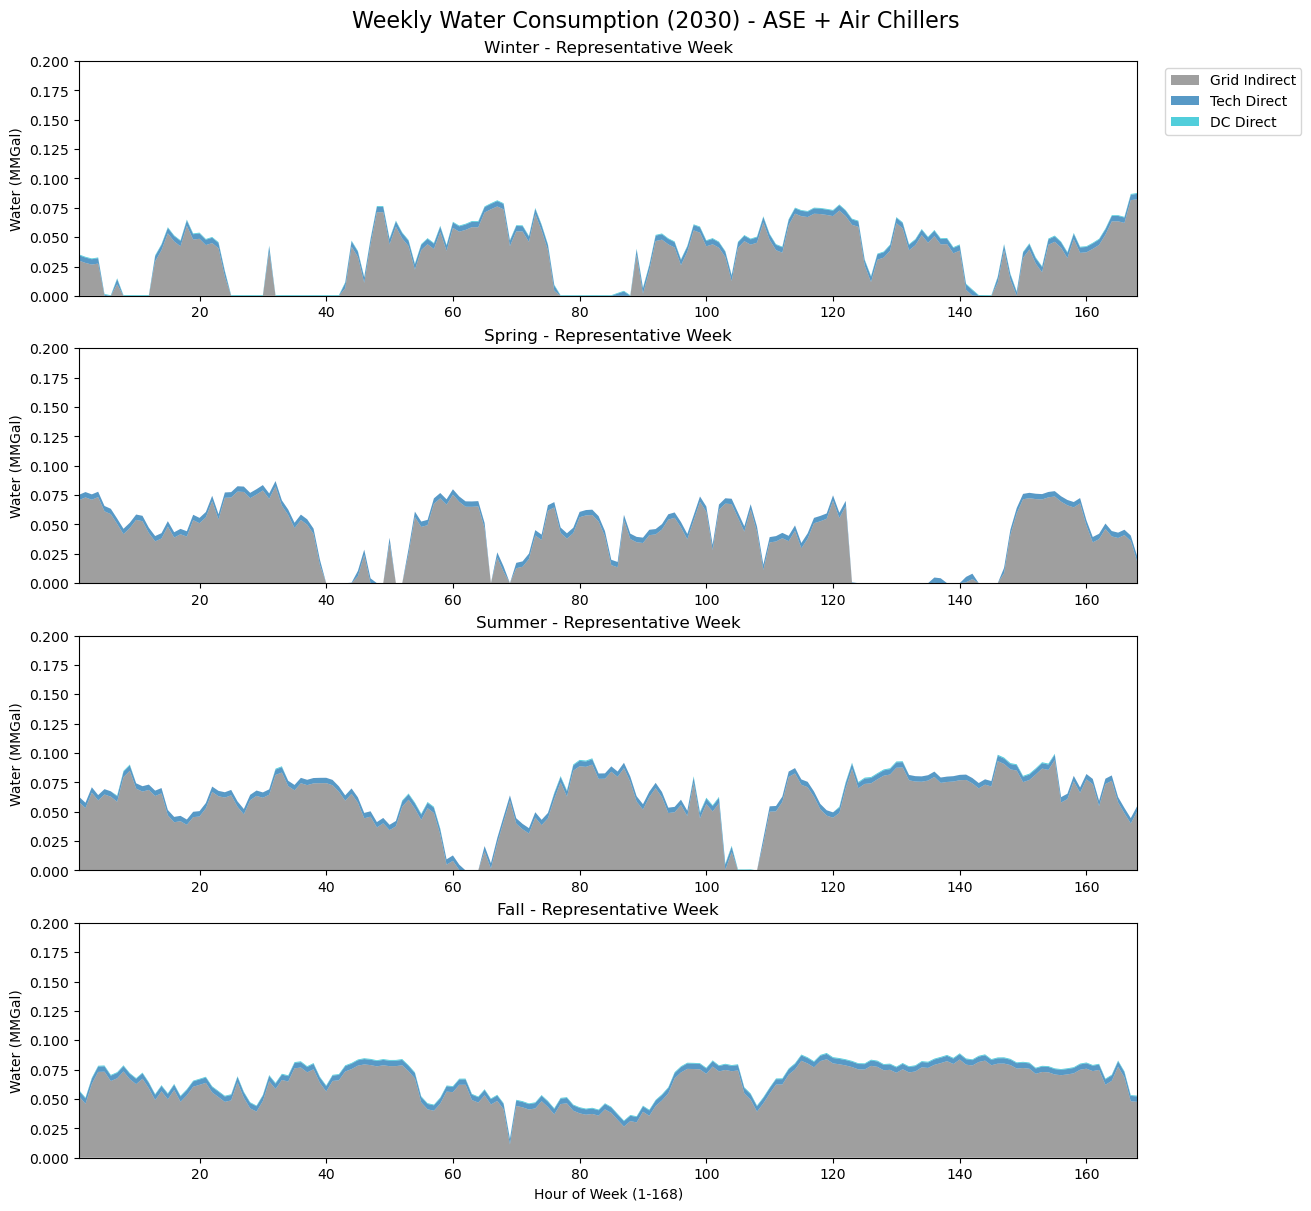

In [20]:
using JLD2, FileIO, PyPlot, XLSX, DataFrames

# ==============================================================================
# 1. SETUP & DATA LOADING
# ==============================================================================
excel_path = "Model_Data.xlsx"
case1_path = "Results_DC_Case_1.jld2"
case6_path = "Results_DC_Case_6.jld2"

seasons = Dict(
    "Winter" => 1001:1168,  # Mid-February
    "Spring" => 3201:3368,  # Mid-May
    "Summer" => 5401:5568,  # Mid-August
    "Fall"   => 7601:7768   # Mid-November
)
ordered_seasons = ["Winter", "Spring", "Summer", "Fall"]

function get_model_parameters(xf)
    println("   > Reading Model Parameters...")
    df_scalars = DataFrame(XLSX.gettable(xf["Model_Data"]))
    get_scal(p) = filter(row -> row.Parameter == p, df_scalars)[1, :Value]
    
    DC_Cap = Float64(get_scal("DC_Cap"))
    DC_Active = Float64(get_scal("DC_Active"))
    y_i, y_f = Int(get_scal("y_i")), Int(get_scal("y_f"))
    years_list = collect(y_i:y_f)

    df_sets = DataFrame(XLSX.gettable(xf["Sets"]))
    
    # Producers
    t_rows = filter(row -> strip(string(row.set)) == "Tech_el_prod", df_sets)
    tech_prod_list = String.(strip.(string.(t_rows.element)))
    
    # Storage
    st_rows = filter(row -> strip(string(row.set)) == "Tech_st_el", df_sets)
    if isempty(st_rows); st_rows = filter(row -> strip(string(row.set)) == "Tech_st", df_sets); end
    tech_st_list = String.(strip.(string.(st_rows.element)))

    df_tech = DataFrame(XLSX.gettable(xf["Tech_Data"]))
    W_Cons = Dict(uppercase(string(row.Technology)) => Float64(row.W_Cons) * 1e-6 for row in eachrow(df_tech))

    df_emi = DataFrame(XLSX.gettable(xf["Annual_emi"]))
    col_names = names(df_emi); target_col = nothing
    for c in col_names; if lowercase(c) == "w_con_grid"; target_col = Symbol(c); break; end; end
    W_grid_factor = 0.0
    if target_col !== nothing
        row_2030 = filter(row -> row.Year == 2030, df_emi)
        if !isempty(row_2030); W_grid_factor = Float64(row_2030[1, target_col]) * 1e-6; end
    end
    
    df_pue = DataFrame(XLSX.gettable(xf["WUE_PUE_hourly"]))
    unit_conv = 264.172 * 1e-6 
    prof_c1 = Dict(); prof_c6 = Dict()
    for row in eachrow(df_pue)
        h = Int(row.Hour_Sequence)
        prof_c1[h] = (PUE = Float64(row.PUE_Case1), WUE = Float64(row.WUE_Case1) * unit_conv)
        prof_c6[h] = (PUE = Float64(row.PUE_Case6), WUE = Float64(row.WUE_Case6) * unit_conv)
    end

    df_dc = DataFrame(XLSX.gettable(xf["DC_Profile_MV"]))
    dc_shape = Dict(row.hours => row[Symbol("2030")] for row in eachrow(df_dc))

    return (years_list, tech_prod_list, tech_st_list, W_grid_factor, W_Cons, prof_c1, prof_c6, dc_shape, DC_Cap, DC_Active)
end

function rehydrate_variables(jld_path, years_list, tech_list, st_list)
    raw = load(jld_path, "results")
    Pg, Pp, Pch, Pdis = Dict{Tuple{Int,Int},Float64}(), Dict{Tuple{String,Int,Int},Float64}(), Dict{Tuple{String,Int,Int},Float64}(), Dict{Tuple{String,Int,Int},Float64}()

    for (k, v) in raw["P_g"]
        if k isa CartesianIndex; Pg[(k[1], years_list[k[2]])] = v; elseif k isa Tuple; Pg[k] = v; end
    end
    for (k, v) in raw["P_p"]
        if k isa CartesianIndex; if k[1]<=length(tech_list); Pp[(tech_list[k[1]], k[2], years_list[k[3]])] = v; end; elseif k isa Tuple; Pp[k] = v; end
    end
    if haskey(raw, "P_ch") && raw["P_ch"] !== nothing
        for (k, v) in raw["P_ch"]; if k isa CartesianIndex; if k[1]<=length(st_list); Pch[(st_list[k[1]], k[2], years_list[k[3]])] = v; end; elseif k isa Tuple; Pch[k] = v; end; end
    end
    if haskey(raw, "P_dis") && raw["P_dis"] !== nothing
        for (k, v) in raw["P_dis"]; if k isa CartesianIndex; if k[1]<=length(st_list); Pdis[(st_list[k[1]], k[2], years_list[k[3]])] = v; end; elseif k isa Tuple; Pdis[k] = v; end; end
    end
    
    return Pg, Pp, Pch, Pdis
end

# Helper function to enforce stack order: Baseload at bottom, Intermittent middle, Discharge top
function tech_rank(name)
    n = lowercase(name)
    if occursin("nu", n) || occursin("nuclear", n); return 1; end
    if occursin("pv", n) || occursin("solar", n); return 2; end
    if occursin("cg", n) || occursin("ng", n) || occursin("cogen", n); return 3; end 
    if occursin("grid", n); return 4; end
    if occursin("wt", n) || occursin("wind", n); return 5; end
    
    if occursin("discharge", n); return 6; end
    return 10
end

# ==============================================================================
# 2. SEPARATE PLOTTING FUNCTIONS
# ==============================================================================

function plot_weekly_electricity(Pg, Pp, Pch, Pdis, profiles, case_name, dc_shape, DC_Cap, DC_Active, TECH_COLORS; y_min=nothing, y_max=nothing, threshold=1)
    
    fig, axs = subplots(4, 1, figsize=(14, 12), constrained_layout=true)
    fig.suptitle("Weekly Electricity Dispatch (2030) - $case_name", fontsize=18, fontweight="bold")

    for (idx, s_name) in enumerate(ordered_seasons)
        range = seasons[s_name]
        hours = collect(range)
        x_axis = 1:length(hours)
        
        # --- A. DATA PREP (REAL SOLVER VALUES ONLY) ---
        techs = unique([k[1] for k in keys(Pp)])
        gen_arrays = Dict(t => [get(Pp, (t, h, 2030), 0.0) for h in hours] for t in techs)
        grid_import = [get(Pg, (h, 2030), 0.0) for h in hours]
        
        st_techs = unique([k[1] for k in keys(Pdis)])
        raw_dis_arrays = Dict(t => [get(Pdis, (t, h, 2030), 0.0) for h in hours] for t in st_techs)
        raw_ch_arrays  = Dict(t => [get(Pch, (t, h, 2030), 0.0) for h in hours] for t in st_techs)
        
        # Calculate NET Storage Flows
        net_dis_arrays = Dict{String, Vector{Float64}}()
        net_ch_arrays  = Dict{String, Vector{Float64}}()
        
        for t in st_techs
            net_dis_arrays[t] = max.(0.0, raw_dis_arrays[t] .- raw_ch_arrays[t])
            net_ch_arrays[t]  = max.(0.0, raw_ch_arrays[t] .- raw_dis_arrays[t])
        end

        # --- B. EXACT MATHEMATICAL DEMAND LINE CALCULATIONS ---
        total_demand_line = zeros(length(hours))
        total_demand_line .+= grid_import
        for t in techs
            total_demand_line .+= gen_arrays[t]
        end
        for t in st_techs
            total_demand_line .+= raw_dis_arrays[t]
            total_demand_line .-= raw_ch_arrays[t]
        end

        dc_load = [DC_Active * dc_shape[h] * DC_Cap * profiles[h].PUE for h in hours]
        base_demand_line = total_demand_line .- dc_load

        # --- C. POSITIVE STACK (Generation & Net Discharge) ---
        pos_components = []
        if sum(grid_import) > threshold
            push!(pos_components, (tech_rank("Grid"), "Grid", grid_import, TECH_COLORS["Grid"]))
        end
        for t in techs
            if sum(gen_arrays[t]) > threshold
                display_name = (t == "cg_el") ? "Cogen plant" : t 
                push!(pos_components, (tech_rank(display_name), display_name, gen_arrays[t], get(TECH_COLORS, display_name, "black")))
            end
        end
        for t in st_techs
            if sum(net_dis_arrays[t]) > threshold
                lbl = "$t (Discharge)"
                push!(pos_components, (tech_rank(lbl), lbl, net_dis_arrays[t], TECH_COLORS[lbl]))
            end
        end
        
        sort!(pos_components, by = x -> x[1]) # Enforce baseload at the bottom
        
        pos_labels = [comp[2] for comp in pos_components]
        pos_data   = [comp[3] for comp in pos_components]
        pos_colors = [comp[4] for comp in pos_components]

        # --- D. NEGATIVE STACK (Net Charging ONLY) ---
        neg_components = []
        for t in st_techs
            if sum(net_ch_arrays[t]) > threshold
                lbl = "$t (Charge)"
                push!(neg_components, (lbl, net_ch_arrays[t] .* -1.0, TECH_COLORS[lbl])) # Negative for plot
            end
        end
        
        neg_labels = [comp[1] for comp in neg_components]
        neg_data   = [comp[2] for comp in neg_components]
        neg_colors = [comp[3] for comp in neg_components]

        # --- E. PLOTTING ---
        ax = axs[idx]
        
        if !isempty(pos_data)
            ax.stackplot(x_axis, pos_data..., labels=pos_labels, colors=pos_colors, alpha=0.9, edgecolor="none")
        end
        
        if !isempty(neg_data)
            ax.stackplot(x_axis, neg_data..., labels=neg_labels, colors=neg_colors, alpha=0.7, edgecolor="none")
        end
        
        # Plot Mathematically Exact Demand Lines
        ax.plot(x_axis, total_demand_line, color="red", linestyle="-", linewidth=2.0, label="Total Demand (El+DC+Tech)")
        ax.plot(x_axis, base_demand_line, color="black", linestyle=":", linewidth=2.0, label="Base Demand (El+Tech)")
        
        ax.axhline(0, color="black", linewidth=1.0)
        
        ax.set_title("$s_name - Representative Week", fontsize=14)
        ax.set_ylabel("Power Dispatch (MW)", fontsize=12)
        ax.set_xlim(1, 168)
        ax.margins(x=0) 
        
        # Limit adjustments
        if y_min !== nothing && y_max !== nothing
            ax.set_ylim(y_min, y_max)
        elseif y_min !== nothing
            ax.set_ylim(bottom=y_min)
        elseif y_max !== nothing
            ax.set_ylim(top=y_max)
        end
        
        if idx == 1
            ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10, borderaxespad=0.)
        end
    end
    axs[4].set_xlabel("Hour of Week (1-168)", fontsize=12)
    return fig
end


function plot_weekly_water(Pg, Pp, profiles, case_name, W_grid_factor, W_Cons, dc_shape, DC_Cap, DC_Active; y_min=nothing, y_max=nothing, threshold=1e-4)
    
    fig, axs = subplots(4, 1, figsize=(13, 12), constrained_layout=true)
    fig.suptitle("Weekly Water Consumption (2030) - $case_name", fontsize=16)

    for (idx, s_name) in enumerate(ordered_seasons)
        range = seasons[s_name]
        hours = collect(range)
        x_axis = 1:length(hours)
        
        techs = unique([k[1] for k in keys(Pp)])
        grid_import = [get(Pg, (h, 2030), 0.0) for h in hours]
        
        tech_water = zeros(length(hours))
        for t in techs
             gen_arr = [get(Pp, (t, h, 2030), 0.0) for h in hours]
             factor = get(W_Cons, uppercase(t), 0.0)
             tech_water .+= gen_arr .* factor
        end

        dc_water = [ (DC_Active * dc_shape[h] * DC_Cap * profiles[h].PUE) * profiles[h].WUE for h in hours ]
        grid_water = grid_import .* W_grid_factor

        # Filter out components that are too small to plot
        w_stack = []
        w_labels = String[]
        w_colors = String[]

        if sum(grid_water) > threshold
            push!(w_stack, grid_water)
            push!(w_labels, "Grid Indirect")
            push!(w_colors, "tab:gray")
        end
        
        if sum(tech_water) > threshold
            push!(w_stack, tech_water)
            push!(w_labels, "Tech Direct")
            push!(w_colors, "tab:blue")
        end
        
        if sum(dc_water) > threshold
            push!(w_stack, dc_water)
            push!(w_labels, "DC Direct")
            push!(w_colors, "tab:cyan")
        end

        ax = axs[idx]
        
        if !isempty(w_stack)
            ax.stackplot(x_axis, w_stack..., labels=w_labels, colors=w_colors, alpha=0.75)
        end
        
        ax.set_title("$s_name - Representative Week", fontsize=12)
        ax.set_ylabel("Water (MMGal)")
        ax.set_xlim(1, 168)
        ax.margins(x=0)
        
        # Limit adjustments
        if y_min !== nothing && y_max !== nothing
            ax.set_ylim(y_min, y_max)
        elseif y_min !== nothing
            ax.set_ylim(bottom=y_min)
        elseif y_max !== nothing
            ax.set_ylim(top=y_max)
        end
        
        if idx == 1 && !isempty(w_labels)
            ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
        end
    end
    axs[4].set_xlabel("Hour of Week (1-168)")
    return fig
end

# ==============================================================================
# 3. EXECUTE
# ==============================================================================
println("Starting Weekly Analysis...")
xf = XLSX.readxlsx(excel_path)
(years, tech_list, st_list, W_grid, W_Cons, prof_c1, prof_c6, dc_shp, dc_cap, dc_act) = get_model_parameters(xf)

# --- BUILD CONSISTENT COLOR MAP TO MATCH REFERENCE IMAGE ---
TECH_COLORS = Dict{String, Any}()

semantic_colors = Dict(
    "nu" => "green", "nuclear" => "green",
    "pv" => "gold", "solar" => "gold",
    "pv_ro" => "pink", 
    "cg_el" => "brown", "ng" => "brown", "Cogen plant" => "brown",
    "wt" => "orange", "wind" => "orange",
    "Grid" => "gray",
    "li_ion (Discharge)" => "steelblue",
    "bb (Discharge)" => "steelblue",
    "li_ion (Charge)" => "silver",
    "bb (Charge)" => "silver"
)

cmap = get_cmap("tab20").colors
c_idx = 1

all_labels = ["Grid"]
append!(all_labels, tech_list)
append!(all_labels, ["$t (Discharge)" for t in st_list])
append!(all_labels, ["$t (Charge)" for t in st_list])

for lbl in all_labels
    display_name = (lbl == "cg_el") ? "Cogen plant" : lbl 
    
    if haskey(semantic_colors, display_name)
        TECH_COLORS[display_name] = semantic_colors[display_name]
    elseif haskey(semantic_colors, lbl)
        TECH_COLORS[display_name] = semantic_colors[lbl]
    elseif !haskey(TECH_COLORS, display_name)
        TECH_COLORS[display_name] = cmap[mod1(c_idx, 20)]
        c_idx += 1
    end
end
# ----------------------------------

# !!! SET YOUR MANUAL Y-AXIS LIMITS HERE !!!
ELEC_Y_MIN = -200  
ELEC_Y_MAX = 500  

WATER_Y_MIN = 0      
WATER_Y_MAX = 0.2  

# --- CASE 1 (ASE + Evap. Cooling) ---
println("\n--- Generating Plots for ASE + Evap. Cooling ---")
Pg_1, Pp_1, Pch_1, Pdis_1 = rehydrate_variables(case1_path, years, tech_list, st_list)

fig_el_1 = plot_weekly_electricity(Pg_1, Pp_1, Pch_1, Pdis_1, prof_c1, "ASE + Evap. Cooling", dc_shp, dc_cap, dc_act, TECH_COLORS; y_min=ELEC_Y_MIN, y_max=ELEC_Y_MAX)
display(fig_el_1)

fig_w_1 = plot_weekly_water(Pg_1, Pp_1, prof_c1, "ASE + Evap. Cooling", W_grid, W_Cons, dc_shp, dc_cap, dc_act; y_min=WATER_Y_MIN, y_max=WATER_Y_MAX)
display(fig_w_1)

# --- CASE 6 (ASE + Air Chillers) ---
println("\n--- Generating Plots for ASE + Air Chillers ---")
Pg_6, Pp_6, Pch_6, Pdis_6 = rehydrate_variables(case6_path, years, tech_list, st_list)

fig_el_6 = plot_weekly_electricity(Pg_6, Pp_6, Pch_6, Pdis_6, prof_c6, "ASE + Air Chillers", dc_shp, dc_cap, dc_act, TECH_COLORS; y_min=ELEC_Y_MIN, y_max=ELEC_Y_MAX)
display(fig_el_6)

fig_w_6 = plot_weekly_water(Pg_6, Pp_6, prof_c6, "ASE + Air Chillers", W_grid, W_Cons, dc_shp, dc_cap, dc_act; y_min=WATER_Y_MIN, y_max=WATER_Y_MAX)
display(fig_w_6)

println("\nAll plots processed successfully.")

Starting Daily Analysis...
   > Reading Model Parameters...

--- Generating Plots for ASE + Evap. Cooling ---

--- Generating Plots for ASE + Air Chillers ---

All plots processed successfully.


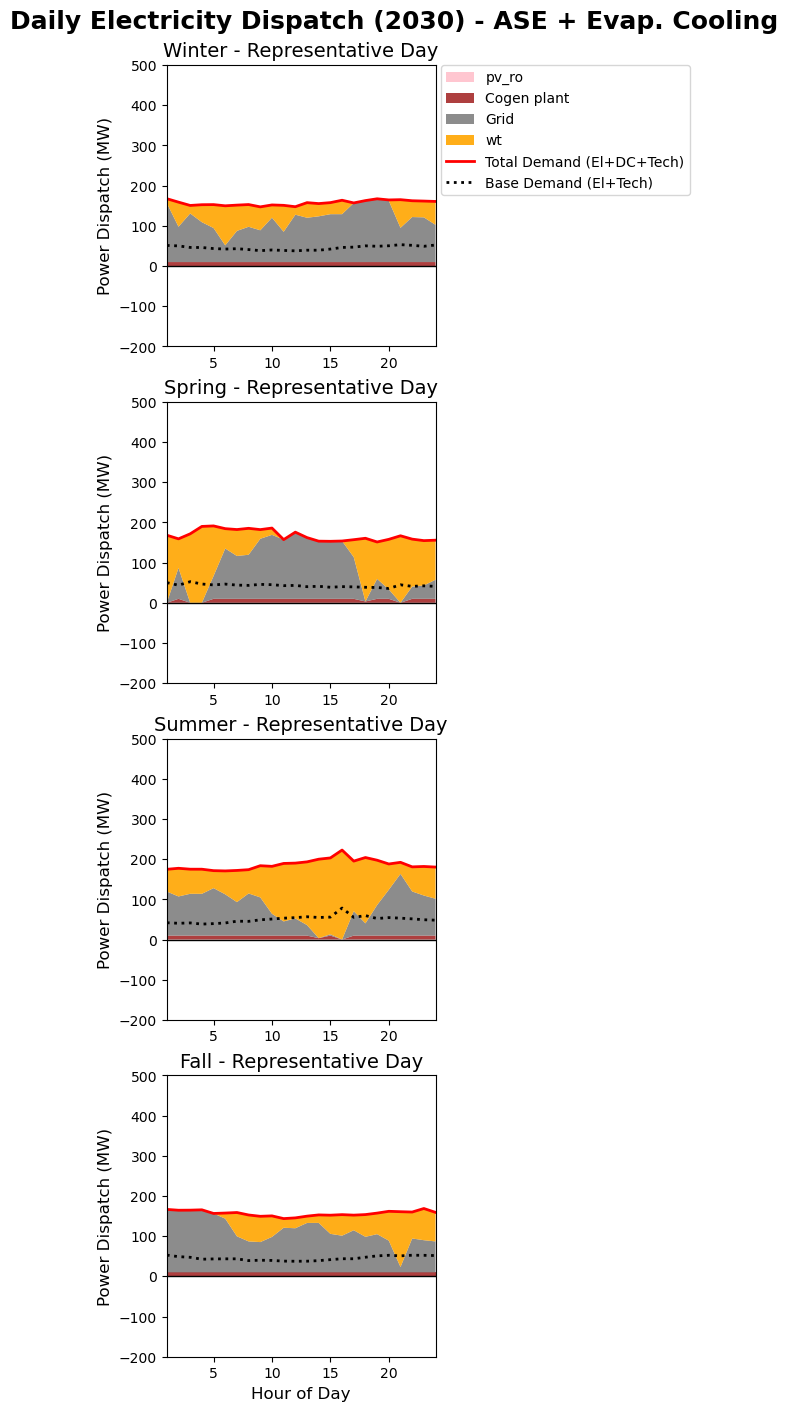

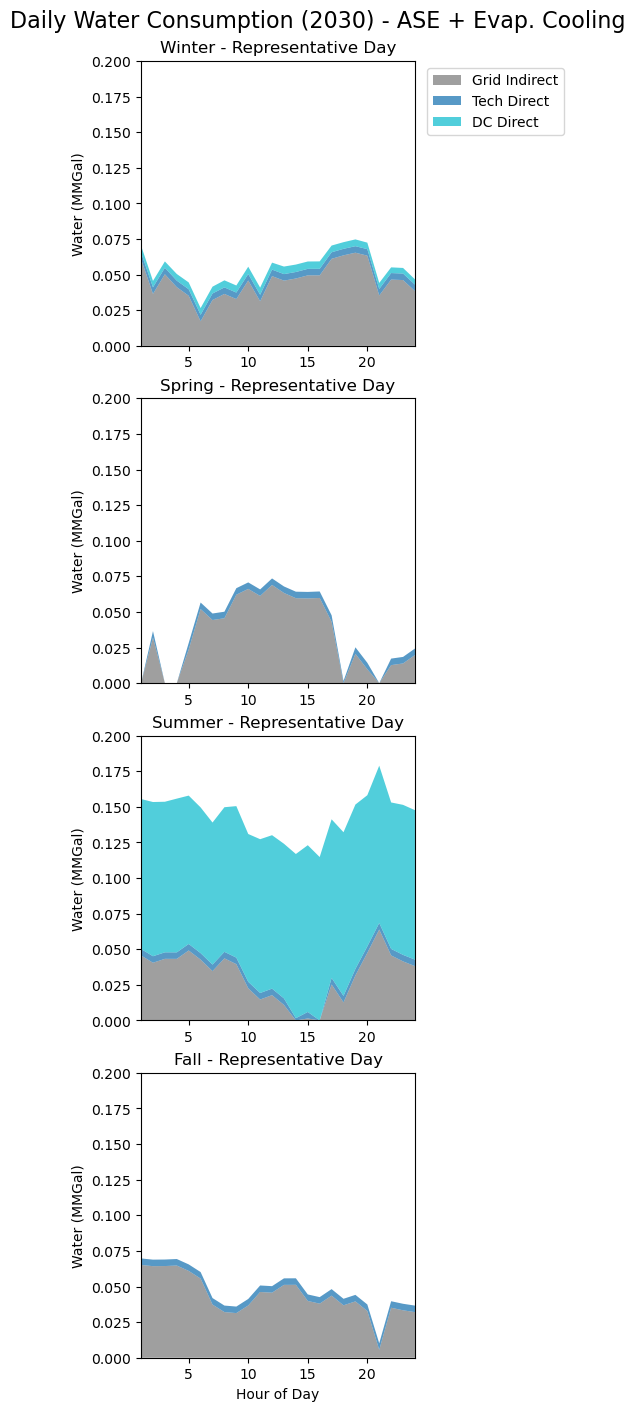

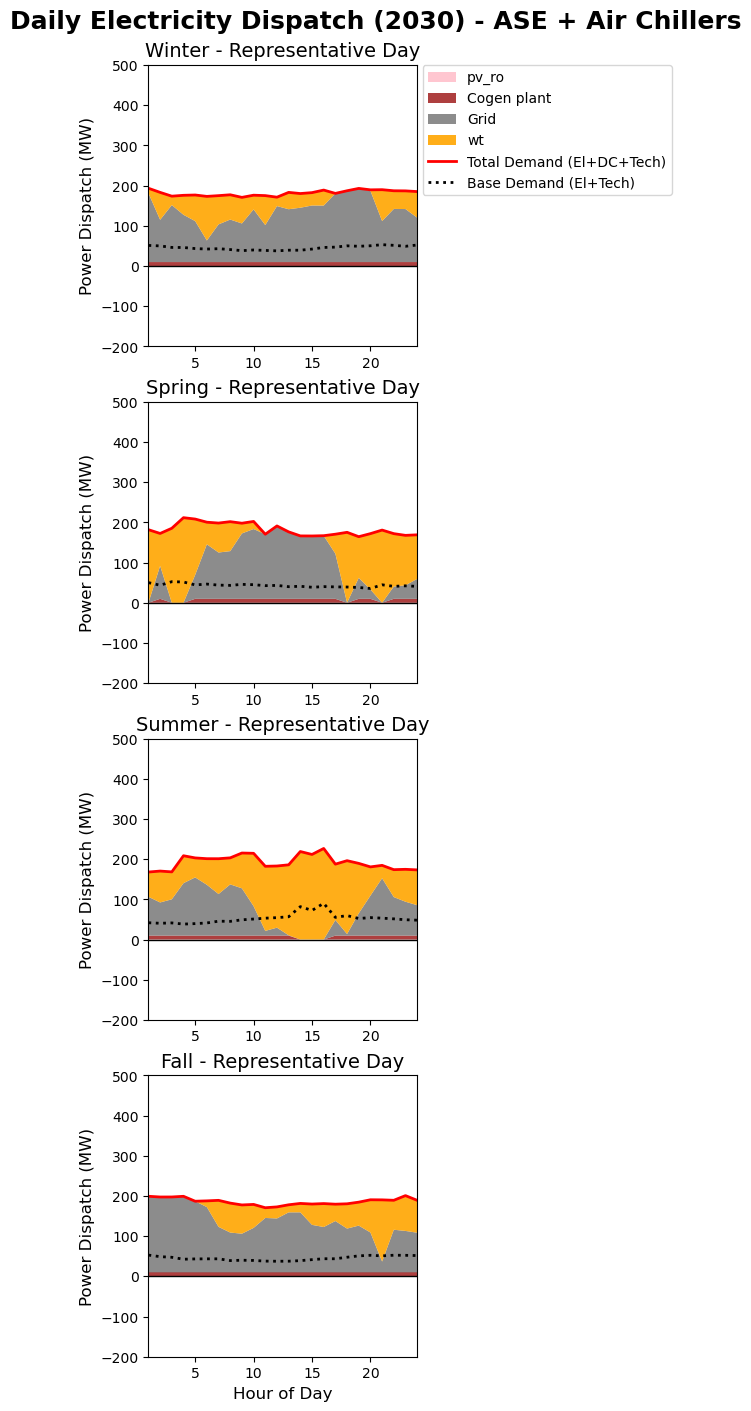

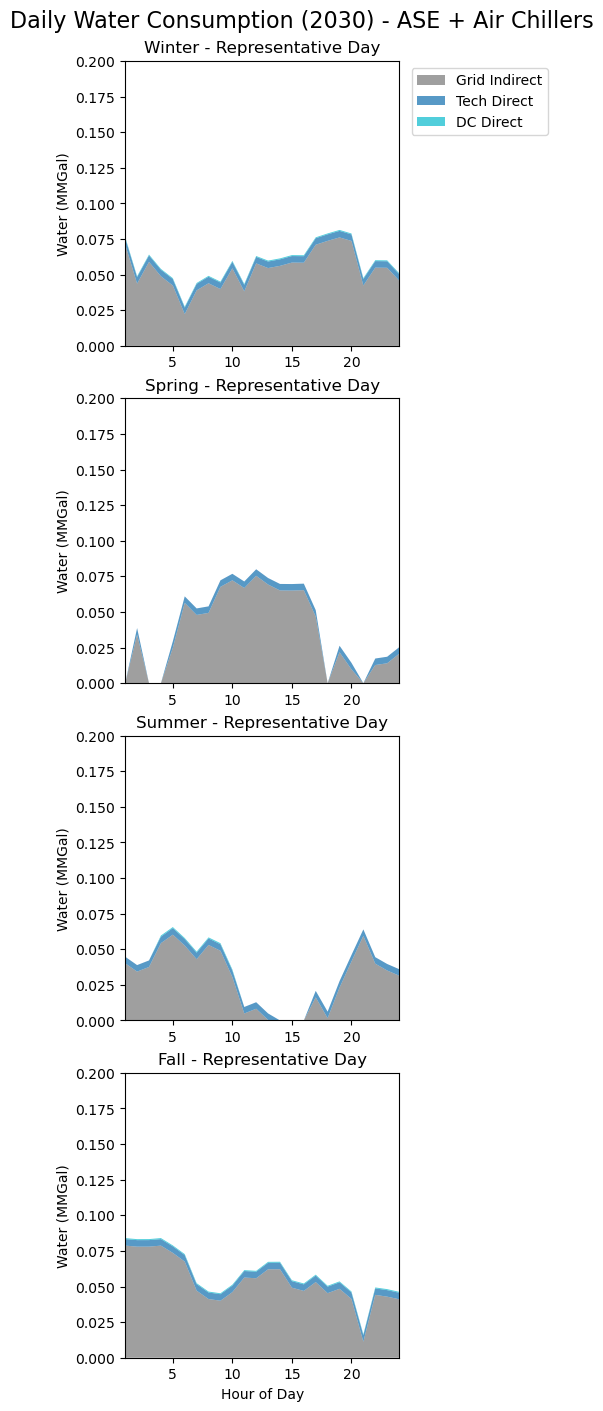

In [18]:
using JLD2, FileIO, PyPlot, XLSX, DataFrames

# ==============================================================================
# 1. SETUP & DATA LOADING
# ==============================================================================
excel_path = "Model_Data.xlsx"
case1_path = "Results_DC_Case_1.jld2"
case6_path = "Results_DC_Case_6.jld2"

seasons = Dict(
    "Winter" => 1001+(2*24):1001+(3*24)-1,  # Mid-February
    "Spring" => 3201+(2*24):3201+(3*24)-1,  # Mid-May
    "Summer" => 5401+(2*24):5401+(3*24)-1,  # Mid-August
    "Fall"   => 7601+(2*24):7601+(3*24)-1   # Mid-November
)
ordered_seasons = ["Winter", "Spring", "Summer", "Fall"]

function get_model_parameters(xf)
    println("   > Reading Model Parameters...")
    df_scalars = DataFrame(XLSX.gettable(xf["Model_Data"]))
    get_scal(p) = filter(row -> row.Parameter == p, df_scalars)[1, :Value]
    
    DC_Cap = Float64(get_scal("DC_Cap"))
    DC_Active = Float64(get_scal("DC_Active"))
    y_i, y_f = Int(get_scal("y_i")), Int(get_scal("y_f"))
    years_list = collect(y_i:y_f)

    df_sets = DataFrame(XLSX.gettable(xf["Sets"]))
    
    # Producers
    t_rows = filter(row -> strip(string(row.set)) == "Tech_el_prod", df_sets)
    tech_prod_list = String.(strip.(string.(t_rows.element)))
    
    # Storage
    st_rows = filter(row -> strip(string(row.set)) == "Tech_st_el", df_sets)
    if isempty(st_rows); st_rows = filter(row -> strip(string(row.set)) == "Tech_st", df_sets); end
    tech_st_list = String.(strip.(string.(st_rows.element)))

    df_tech = DataFrame(XLSX.gettable(xf["Tech_Data"]))
    W_Cons = Dict(uppercase(string(row.Technology)) => Float64(row.W_Cons) * 1e-6 for row in eachrow(df_tech))

    df_emi = DataFrame(XLSX.gettable(xf["Annual_emi"]))
    col_names = names(df_emi); target_col = nothing
    for c in col_names; if lowercase(c) == "w_con_grid"; target_col = Symbol(c); break; end; end
    W_grid_factor = 0.0
    if target_col !== nothing
        row_2030 = filter(row -> row.Year == 2030, df_emi)
        if !isempty(row_2030); W_grid_factor = Float64(row_2030[1, target_col]) * 1e-6; end
    end
    
    df_pue = DataFrame(XLSX.gettable(xf["WUE_PUE_hourly"]))
    unit_conv = 264.172 * 1e-6 
    prof_c1 = Dict(); prof_c6 = Dict()
    for row in eachrow(df_pue)
        h = Int(row.Hour_Sequence)
        prof_c1[h] = (PUE = Float64(row.PUE_Case1), WUE = Float64(row.WUE_Case1) * unit_conv)
        prof_c6[h] = (PUE = Float64(row.PUE_Case6), WUE = Float64(row.WUE_Case6) * unit_conv)
    end

    df_dc = DataFrame(XLSX.gettable(xf["DC_Profile_MV"]))
    dc_shape = Dict(row.hours => row[Symbol("2030")] for row in eachrow(df_dc))

    return (years_list, tech_prod_list, tech_st_list, W_grid_factor, W_Cons, prof_c1, prof_c6, dc_shape, DC_Cap, DC_Active)
end

function rehydrate_variables(jld_path, years_list, tech_list, st_list)
    raw = load(jld_path, "results")
    Pg, Pp, Pch, Pdis = Dict{Tuple{Int,Int},Float64}(), Dict{Tuple{String,Int,Int},Float64}(), Dict{Tuple{String,Int,Int},Float64}(), Dict{Tuple{String,Int,Int},Float64}()

    for (k, v) in raw["P_g"]
        if k isa CartesianIndex; Pg[(k[1], years_list[k[2]])] = v; elseif k isa Tuple; Pg[k] = v; end
    end
    for (k, v) in raw["P_p"]
        if k isa CartesianIndex; if k[1]<=length(tech_list); Pp[(tech_list[k[1]], k[2], years_list[k[3]])] = v; end; elseif k isa Tuple; Pp[k] = v; end
    end
    if haskey(raw, "P_ch") && raw["P_ch"] !== nothing
        for (k, v) in raw["P_ch"]; if k isa CartesianIndex; if k[1]<=length(st_list); Pch[(st_list[k[1]], k[2], years_list[k[3]])] = v; end; elseif k isa Tuple; Pch[k] = v; end; end
    end
    if haskey(raw, "P_dis") && raw["P_dis"] !== nothing
        for (k, v) in raw["P_dis"]; if k isa CartesianIndex; if k[1]<=length(st_list); Pdis[(st_list[k[1]], k[2], years_list[k[3]])] = v; end; elseif k isa Tuple; Pdis[k] = v; end; end
    end
    
    return Pg, Pp, Pch, Pdis
end

# Helper function to enforce stack order: Baseload at bottom, Intermittent middle, Discharge top
function tech_rank(name)
    n = lowercase(name)
    if occursin("nu", n) || occursin("nuclear", n); return 1; end
    if occursin("pv", n) || occursin("solar", n); return 2; end
    if occursin("cg", n) || occursin("ng", n) || occursin("cogen", n); return 3; end 
    if occursin("grid", n); return 4; end
    if occursin("wt", n) || occursin("wind", n); return 5; end
    
    if occursin("discharge", n); return 6; end
    return 10
end

# ==============================================================================
# 2. SEPARATE PLOTTING FUNCTIONS
# ==============================================================================

function plot_daily_electricity(Pg, Pp, Pch, Pdis, profiles, case_name, dc_shape, DC_Cap, DC_Active, TECH_COLORS; y_min=nothing, y_max=nothing, threshold=0.1)
    
    fig, axs = subplots(4, 1, figsize=(6, 14), constrained_layout=true)
    fig.suptitle("Daily Electricity Dispatch (2030) - $case_name", fontsize=18, fontweight="bold")

    for (idx, s_name) in enumerate(ordered_seasons)
        range = seasons[s_name]
        hours = collect(range)
        x_axis = 1:length(hours)
        
        # --- A. DATA PREP (REAL SOLVER VALUES ONLY) ---
        techs = unique([k[1] for k in keys(Pp)])
        gen_arrays = Dict(t => [get(Pp, (t, h, 2030), 0.0) for h in hours] for t in techs)
        grid_import = [get(Pg, (h, 2030), 0.0) for h in hours]
        
        st_techs = unique([k[1] for k in keys(Pdis)])
        raw_dis_arrays = Dict(t => [get(Pdis, (t, h, 2030), 0.0) for h in hours] for t in st_techs)
        raw_ch_arrays  = Dict(t => [get(Pch, (t, h, 2030), 0.0) for h in hours] for t in st_techs)
        
        # Calculate NET Storage Flows
        net_dis_arrays = Dict{String, Vector{Float64}}()
        net_ch_arrays  = Dict{String, Vector{Float64}}()
        
        for t in st_techs
            net_dis_arrays[t] = max.(0.0, raw_dis_arrays[t] .- raw_ch_arrays[t])
            net_ch_arrays[t]  = max.(0.0, raw_ch_arrays[t] .- raw_dis_arrays[t])
        end

        # --- B. EXACT MATHEMATICAL DEMAND LINE CALCULATIONS ---
        total_demand_line = zeros(length(hours))
        total_demand_line .+= grid_import
        for t in techs
            total_demand_line .+= gen_arrays[t]
        end
        for t in st_techs
            total_demand_line .+= raw_dis_arrays[t]
            total_demand_line .-= raw_ch_arrays[t]
        end

        dc_load = [DC_Active * dc_shape[h] * DC_Cap * profiles[h].PUE for h in hours]
        base_demand_line = total_demand_line .- dc_load

        # --- C. POSITIVE STACK (Generation & Net Discharge) ---
        pos_components = []
        if sum(grid_import) > threshold
            push!(pos_components, (tech_rank("Grid"), "Grid", grid_import, TECH_COLORS["Grid"]))
        end
        for t in techs
            if sum(gen_arrays[t]) > threshold
                display_name = (t == "cg_el") ? "Cogen plant" : t 
                push!(pos_components, (tech_rank(display_name), display_name, gen_arrays[t], get(TECH_COLORS, display_name, "black")))
            end
        end
        for t in st_techs
            if sum(net_dis_arrays[t]) > threshold
                lbl = "$t (Discharge)"
                push!(pos_components, (tech_rank(lbl), lbl, net_dis_arrays[t], TECH_COLORS[lbl]))
            end
        end
        
        sort!(pos_components, by = x -> x[1]) # Enforce baseload at the bottom
        
        pos_labels = [comp[2] for comp in pos_components]
        pos_data   = [comp[3] for comp in pos_components]
        pos_colors = [comp[4] for comp in pos_components]

        # --- D. NEGATIVE STACK (Net Charging ONLY) ---
        neg_components = []
        for t in st_techs
            if sum(net_ch_arrays[t]) > threshold
                lbl = "$t (Charge)"
                push!(neg_components, (lbl, net_ch_arrays[t] .* -1.0, TECH_COLORS[lbl])) # Negative for plot
            end
        end
        
        neg_labels = [comp[1] for comp in neg_components]
        neg_data   = [comp[2] for comp in neg_components]
        neg_colors = [comp[3] for comp in neg_components]

        # --- E. PLOTTING ---
        ax = axs[idx]
        
        if !isempty(pos_data)
            ax.stackplot(x_axis, pos_data..., labels=pos_labels, colors=pos_colors, alpha=0.9, edgecolor="none")
        end
        
        if !isempty(neg_data)
            ax.stackplot(x_axis, neg_data..., labels=neg_labels, colors=neg_colors, alpha=0.7, edgecolor="none")
        end
        
        # Plot Mathematically Exact Demand Lines
        ax.plot(x_axis, total_demand_line, color="red", linestyle="-", linewidth=2.0, label="Total Demand (El+DC+Tech)")
        ax.plot(x_axis, base_demand_line, color="black", linestyle=":", linewidth=2.0, label="Base Demand (El+Tech)")
        
        ax.axhline(0, color="black", linewidth=1.0)
        
        ax.set_title("$s_name - Representative Day", fontsize=14)
        ax.set_ylabel("Power Dispatch (MW)", fontsize=12)
        ax.set_xlim(1, length(hours))
        ax.margins(x=0) 
        
        # Limit adjustments
        if y_min !== nothing && y_max !== nothing
            ax.set_ylim(y_min, y_max)
        elseif y_min !== nothing
            ax.set_ylim(bottom=y_min)
        elseif y_max !== nothing
            ax.set_ylim(top=y_max)
        end
        
        if idx == 1
            ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10, borderaxespad=0.)
        end
    end
    axs[4].set_xlabel("Hour of Day", fontsize=12)
    return fig
end


function plot_daily_water(Pg, Pp, profiles, case_name, W_grid_factor, W_Cons, dc_shape, DC_Cap, DC_Active; y_min=nothing, y_max=nothing, threshold=1e-4)
    
    fig, axs = subplots(4, 1, figsize=(5, 14), constrained_layout=true)
    fig.suptitle("Daily Water Consumption (2030) - $case_name", fontsize=16)

    for (idx, s_name) in enumerate(ordered_seasons)
        range = seasons[s_name]
        hours = collect(range)
        x_axis = 1:length(hours)
        
        techs = unique([k[1] for k in keys(Pp)])
        grid_import = [get(Pg, (h, 2030), 0.0) for h in hours]
        
        tech_water = zeros(length(hours))
        for t in techs
             gen_arr = [get(Pp, (t, h, 2030), 0.0) for h in hours]
             factor = get(W_Cons, uppercase(t), 0.0)
             tech_water .+= gen_arr .* factor
        end

        dc_water = [ (DC_Active * dc_shape[h] * DC_Cap * profiles[h].PUE) * profiles[h].WUE for h in hours ]
        grid_water = grid_import .* W_grid_factor

        # Filter out components that are too small to plot
        w_stack = []
        w_labels = String[]
        w_colors = String[]

        if sum(grid_water) > threshold
            push!(w_stack, grid_water)
            push!(w_labels, "Grid Indirect")
            push!(w_colors, "tab:gray")
        end
        
        if sum(tech_water) > threshold
            push!(w_stack, tech_water)
            push!(w_labels, "Tech Direct")
            push!(w_colors, "tab:blue")
        end
        
        if sum(dc_water) > threshold
            push!(w_stack, dc_water)
            push!(w_labels, "DC Direct")
            push!(w_colors, "tab:cyan")
        end

        ax = axs[idx]
        
        if !isempty(w_stack)
            ax.stackplot(x_axis, w_stack..., labels=w_labels, colors=w_colors, alpha=0.75)
        end
        
        ax.set_title("$s_name - Representative Day", fontsize=12)
        ax.set_ylabel("Water (MMGal)")
        ax.set_xlim(1, length(hours))
        ax.margins(x=0)
        
        # Limit adjustments
        if y_min !== nothing && y_max !== nothing
            ax.set_ylim(y_min, y_max)
        elseif y_min !== nothing
            ax.set_ylim(bottom=y_min)
        elseif y_max !== nothing
            ax.set_ylim(top=y_max)
        end
        
        if idx == 1 && !isempty(w_labels)
            ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
        end
    end
    axs[4].set_xlabel("Hour of Day")
    return fig
end

# ==============================================================================
# 3. EXECUTE
# ==============================================================================
println("Starting Daily Analysis...")
xf = XLSX.readxlsx(excel_path)
(years, tech_list, st_list, W_grid, W_Cons, prof_c1, prof_c6, dc_shp, dc_cap, dc_act) = get_model_parameters(xf)

# --- BUILD CONSISTENT COLOR MAP TO MATCH REFERENCE IMAGE ---
TECH_COLORS = Dict{String, Any}()

semantic_colors = Dict(
    "nu" => "green", "nuclear" => "green",
    "pv" => "gold", "solar" => "gold",
    "pv_ro" => "pink", 
    "cg_el" => "brown", "ng" => "brown", "Cogen plant" => "brown",
    "wt" => "orange", "wind" => "orange",
    "Grid" => "gray",
    "li_ion (Discharge)" => "steelblue",
    "bb (Discharge)" => "steelblue",
    "li_ion (Charge)" => "silver",
    "bb (Charge)" => "silver"
)

cmap = get_cmap("tab20").colors
c_idx = 1

all_labels = ["Grid"]
append!(all_labels, tech_list)
append!(all_labels, ["$t (Discharge)" for t in st_list])
append!(all_labels, ["$t (Charge)" for t in st_list])

for lbl in all_labels
    display_name = (lbl == "cg_el") ? "Cogen plant" : lbl 
    
    if haskey(semantic_colors, display_name)
        TECH_COLORS[display_name] = semantic_colors[display_name]
    elseif haskey(semantic_colors, lbl)
        TECH_COLORS[display_name] = semantic_colors[lbl]
    elseif !haskey(TECH_COLORS, display_name)
        TECH_COLORS[display_name] = cmap[mod1(c_idx, 20)]
        c_idx += 1
    end
end
# ----------------------------------

# !!! SET YOUR MANUAL Y-AXIS LIMITS HERE !!!
ELEC_Y_MIN = -200     
ELEC_Y_MAX = 500    

WATER_Y_MIN = 0      
WATER_Y_MAX = 0.2 

# --- CASE 1 (ASE + Evap. Cooling) ---
println("\n--- Generating Plots for ASE + Evap. Cooling ---")
Pg_1, Pp_1, Pch_1, Pdis_1 = rehydrate_variables(case1_path, years, tech_list, st_list)

fig_el_1 = plot_daily_electricity(Pg_1, Pp_1, Pch_1, Pdis_1, prof_c1, "ASE + Evap. Cooling", dc_shp, dc_cap, dc_act, TECH_COLORS; y_min=ELEC_Y_MIN, y_max=ELEC_Y_MAX)
display(fig_el_1)

fig_w_1 = plot_daily_water(Pg_1, Pp_1, prof_c1, "ASE + Evap. Cooling", W_grid, W_Cons, dc_shp, dc_cap, dc_act; y_min=WATER_Y_MIN, y_max=WATER_Y_MAX)
display(fig_w_1)

# --- CASE 6 (ASE + Air Chillers) ---
println("\n--- Generating Plots for ASE + Air Chillers ---")
Pg_6, Pp_6, Pch_6, Pdis_6 = rehydrate_variables(case6_path, years, tech_list, st_list)

fig_el_6 = plot_daily_electricity(Pg_6, Pp_6, Pch_6, Pdis_6, prof_c6, "ASE + Air Chillers", dc_shp, dc_cap, dc_act, TECH_COLORS; y_min=ELEC_Y_MIN, y_max=ELEC_Y_MAX)
display(fig_el_6)

fig_w_6 = plot_daily_water(Pg_6, Pp_6, prof_c6, "ASE + Air Chillers", W_grid, W_Cons, dc_shp, dc_cap, dc_act; y_min=WATER_Y_MIN, y_max=WATER_Y_MAX)
display(fig_w_6)

println("\nAll plots processed successfully.")